# Practice Resolution - Maritime Port Activity

In [149]:
import pandas as pd
import requests
from datetime import datetime
import geopandas as gpd
from shapely import Point
from plotnine import *
from mizani.breaks import date_breaks
from mizani.formatters import date_format, percent_format, comma_format
import numpy as np

import warnings
warnings.filterwarnings('ignore')


## Monthly Trade Charts

Given that there are several weeks with no trade data in the PortWatch dataset, please recreate the "Weekly Trade Volume" plots from above by changing the aggregation level from weekly to monthly. 

In [103]:
def api_call(url):
    '''Make an API call and return a GDF'''
    res = requests.get(url)
    df = pd.DataFrame([d["attributes"] for d in res.json()["features"]])
    return df

def create_gdf(data, epsg, lat, lon):
    '''Create a GDF from a csv with lat and lon'''
    geometry = data.apply(lambda row: Point(row[lon], row[lat]), axis = 1)
    return gpd.GeoDataFrame(data, crs = epsg, geometry = geometry)

In [3]:
countries = ["Egypt", "Yemen", "Djibouti", "Jordan", "Saudi Arabia"]
ports = api_call("https://services9.arcgis.com/weJ1QsnbMYJlCHdG/arcgis/rest/services/PortWatch_ports_database/FeatureServer/0/query?where=1%3D1&outFields=*&outSR=4326&f=json")
ports_oi = ports[ports['country'].isin(countries)]
ports_red_sea = create_gdf(ports_oi, 'EPSG:4326', 'lat', 'lon')

In [6]:
def get_port_data(ports, url_base):
    for port in ports:
        if port == ports[-1]:
            url_base += (
                f"portid%3D%27{port}%27&outFields=*&outSR=4326&f=json&resultOffset=0"
            )
        else:
            url_base += f"portid%3D%27{port}%27+OR+"
    res = requests.get(url_base)
    df = pd.DataFrame([d["attributes"] for d in res.json()["features"]])
    offset = 1000
    while len(df) % 1000 == 0:
        res = requests.get(url_base.replace("resultOffset=0", f"resultOffset={offset}"))
        df2 = pd.DataFrame([d["attributes"] for d in res.json()["features"]])
        df = pd.concat([df, df2])
        offset += 1000
    df.reset_index(inplace=True, drop=True)
    df["date"] = df.date.apply(lambda x: datetime.fromtimestamp(x / 1000))
    df.sort_values(["portid", "date"], inplace=True)
    return df

url_base = "https://services9.arcgis.com/weJ1QsnbMYJlCHdG/arcgis/rest/services/Daily_Trade_Data/FeatureServer/0/query?where="
ports = list(ports_red_sea.portid)
df_ports = get_port_data(ports, url_base)
df_ports.to_csv('ports_call.csv') # save the call locally to avoid repeating it

In [150]:
df = pd.read_csv('ports_call.csv')
df.date = pd.to_datetime(df.date)
df = df.loc[df.date >= "2019-01-01"].copy()

In [151]:
df_month = df.groupby(["portname", "portid"])[
    [
        "portcalls_cargo",
        "portcalls_tanker",
        "portcalls",
        "import_cargo",
        "export_cargo",
        "import_tanker",
        "export_tanker",
        "import",
        "export",
        "date",
    ]].resample("ME", on="date").sum().reset_index()

df_month["ymd"] = df_month.date.dt.strftime("%Y-%m-%d")
df_month["month"] = df_month.date.dt.strftime("%m")  # Month number of the year

In [152]:
start_reference_date = "2022-01-01"
conflict_date = "2023-10-07"
crisis_date = "2023-11-17"

df_ref_month = df_month.loc[(df_month.date >= start_reference_date) & (df_month.date < conflict_date)].copy()
df_ref_month = df_ref_month.groupby(["portname", "portid", "month"])[
    [
        "portcalls_cargo",
        "portcalls_tanker",
        "portcalls",
        "import_cargo",
        "export_cargo",
        "import_tanker",
        "export_tanker",
        "import",
        "export",
    ]
].mean()

df_ref_month.reset_index(inplace=True)
df_ref_month.rename(
    columns={
        "portcalls_cargo": "portcalls_cargo_ref",
        "portcalls_tanker": "portcalls_tanker_ref",
        "portcalls": "portcalls_ref",
        "import_cargo": "import_cargo_ref",
        "export_cargo": "export_cargo_ref",
        "import_tanker": "import_tanker_ref",
        "export_tanker": "export_tanker_ref",
        "import": "import_ref",
        "export": "export_ref",
    },
    inplace=True,
)

# Merge reference data into the filtered monthly data
df_month = df_month.merge(
    df_ref_month, on=["portname", "portid", "month"], how="left", validate="m:1"
)


In [153]:
df_month

,portname,portid,date,portcalls_cargo,portcalls_tanker,portcalls,import_cargo,export_cargo,import_tanker,export_tanker,...,month,portcalls_cargo_ref,portcalls_tanker_ref,portcalls_ref,import_cargo_ref,export_cargo_ref,import_tanker_ref,export_tanker_ref,import_ref,export_ref
0,Aden,port9,2019-01-31,35,7,42,233138.229104,13672.701248,61496.118007,3160.095388,...,01,30.5,8.5,39.0,270316.714235,5602.033744,59738.885023,18787.279794,330055.599257,24389.313537
1,Aden,port9,2019-02-28,43,5,48,354860.083005,9959.739240,43778.311268,6320.190776,...,02,28.0,8.0,36.0,253415.504328,19770.638437,69333.081688,8097.441062,322748.586016,27868.079499
2,Aden,port9,2019-03-31,44,2,46,355782.326575,12201.081744,0.000000,2976.724747,...,03,29.0,5.5,34.5,285299.318435,8283.061961,58112.015114,3291.337903,343411.333549,11574.399865
3,Aden,port9,2019-04-30,42,9,51,420678.411302,10664.030795,101798.953706,3160.095388,...,04,21.0,8.5,29.5,172310.871374,5654.288546,27834.493651,23295.787230,200145.365024,28950.075776
4,Aden,port9,2019-05-31,33,8,41,371243.803323,16243.093222,107065.868521,0.000000,...,05,30.5,5.0,35.5,300332.279651,2940.532900,30973.479046,416.764512,331305.758697,3357.297411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1723,Yanbu,port1408,2024-08-31,13,5,18,170799.561717,97929.761702,16534.906080,16636.639370,...,08,12.0,2.0,14.0,154253.297281,68422.541326,10273.802867,0.000000,164527.100148,68422.541326
1724,Yanbu,port1408,2024-09-30,18,2,20,115835.276472,197643.951985,4826.968384,0.000000,...,09,7.0,2.0,9.0,86349.417354,46285.938124,14704.887874,0.000000,101054.305228,46285.938124
1725,Yanbu,port1408,2024-10-31,7,2,9,17532.673056,18197.785387,10221.405897,0.000000,...,10,10.0,3.0,13.0,158511.803913,43266.381177,2941.521529,0.000000,161453.325442,43266.381177
1726,Yanbu,port1408,2024-11-30,14,2,16,151936.707171,110518.266785,15167.467606,0.000000,...,11,10.0,3.0,13.0,168725.983855,111558.979900,1081.666508,1589.215699,169807.650364,113148.195599


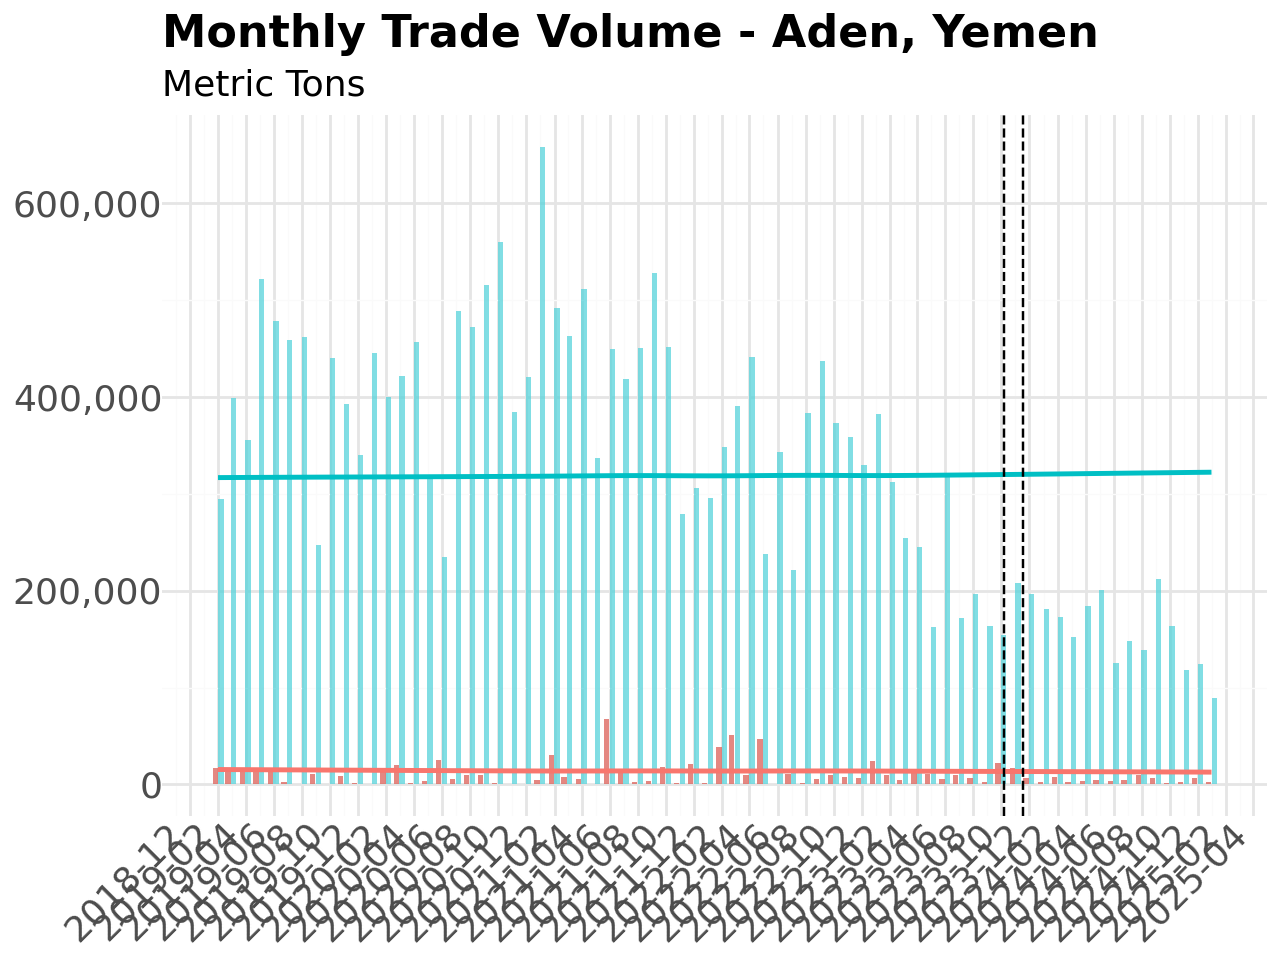

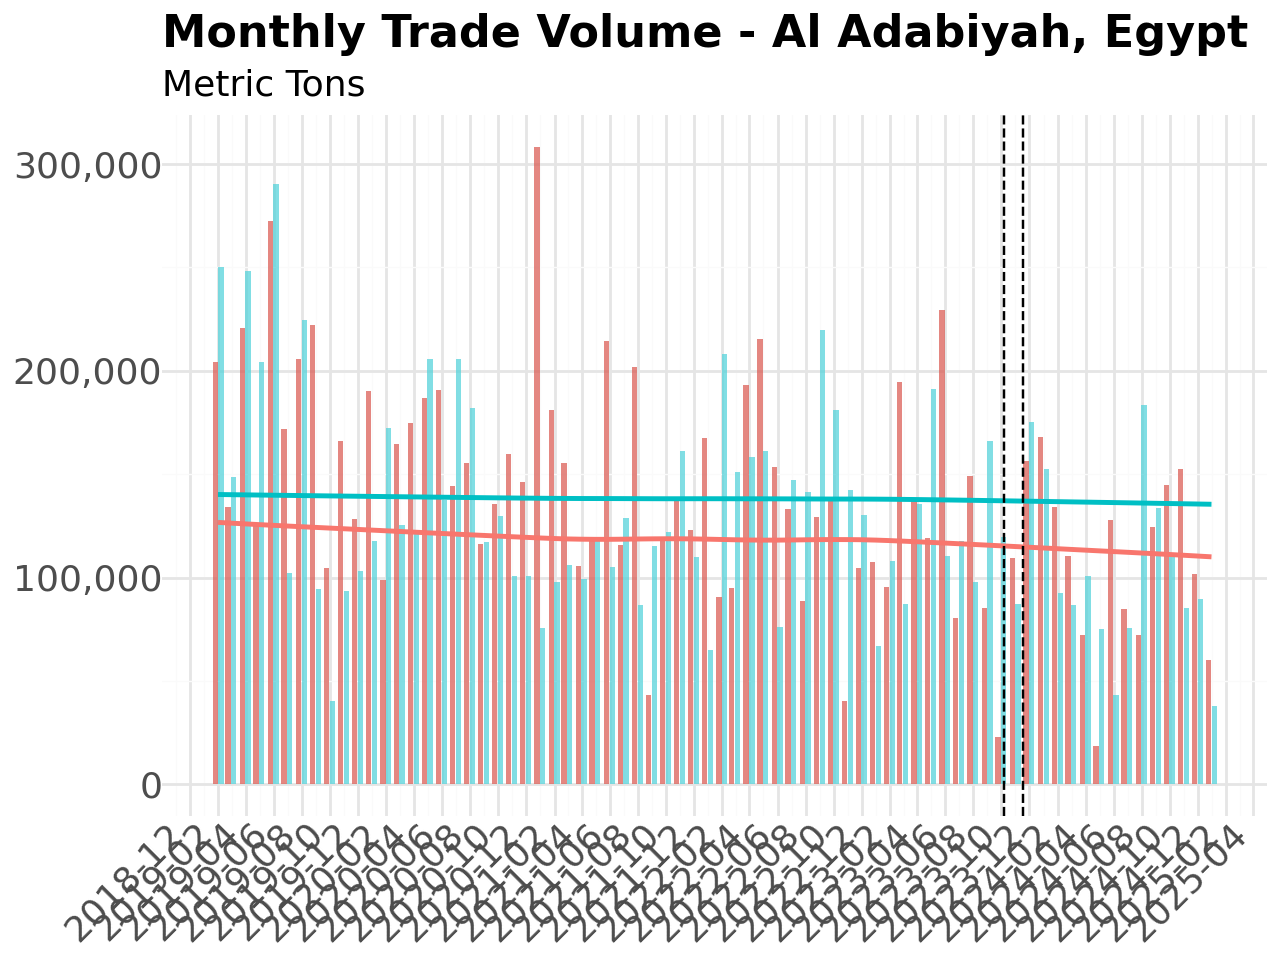

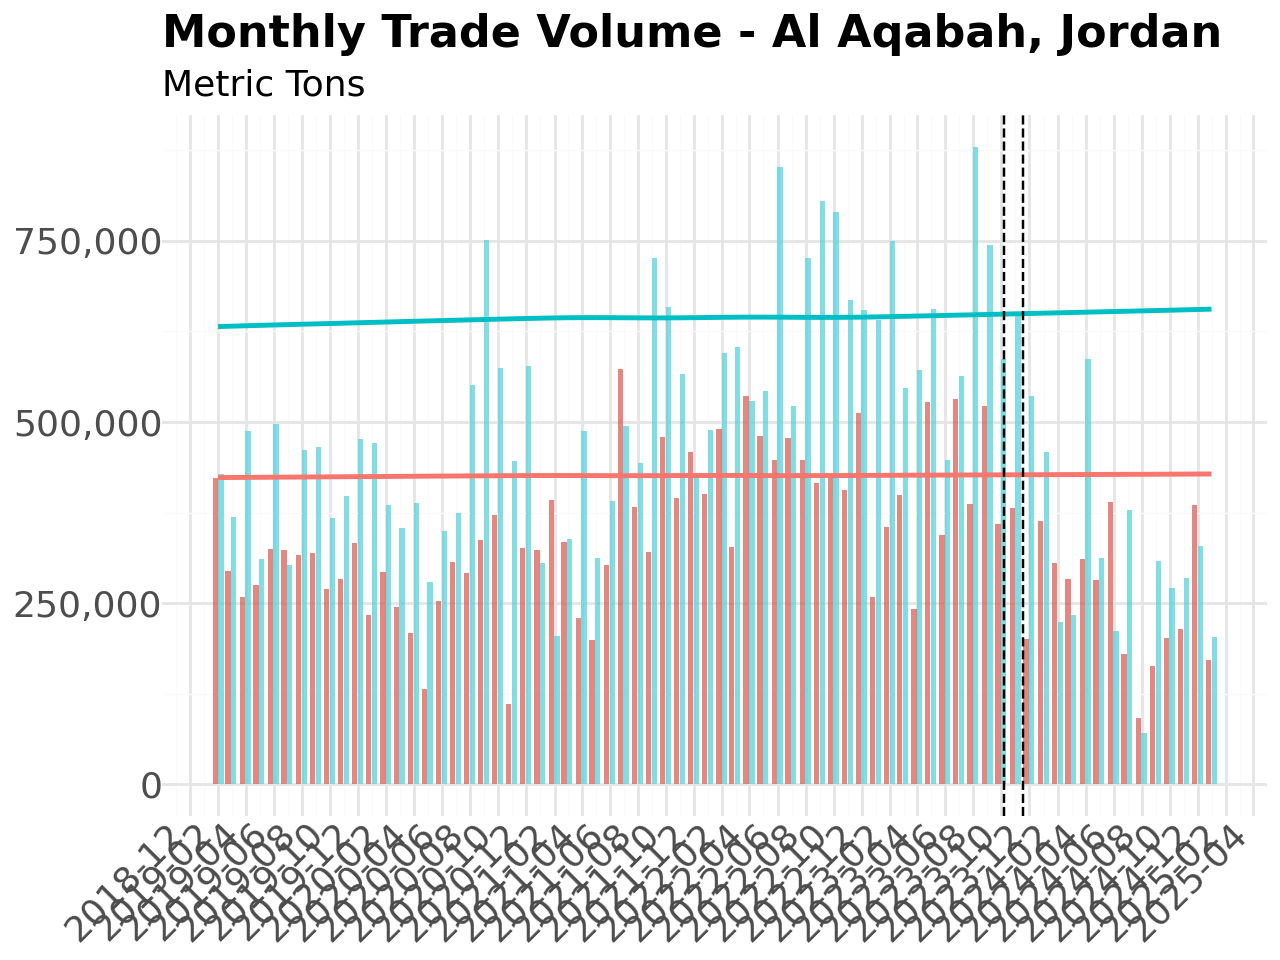

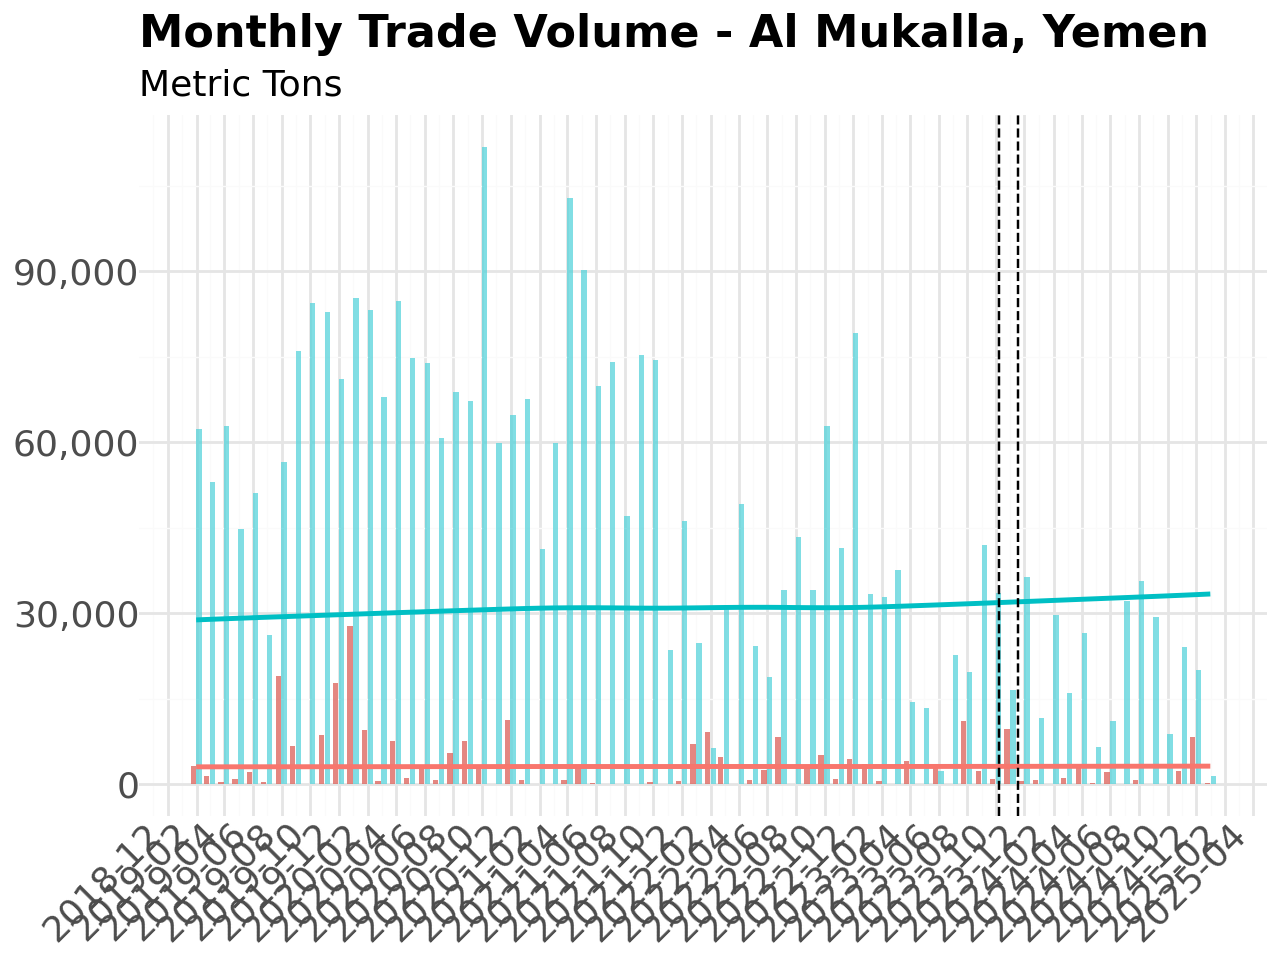

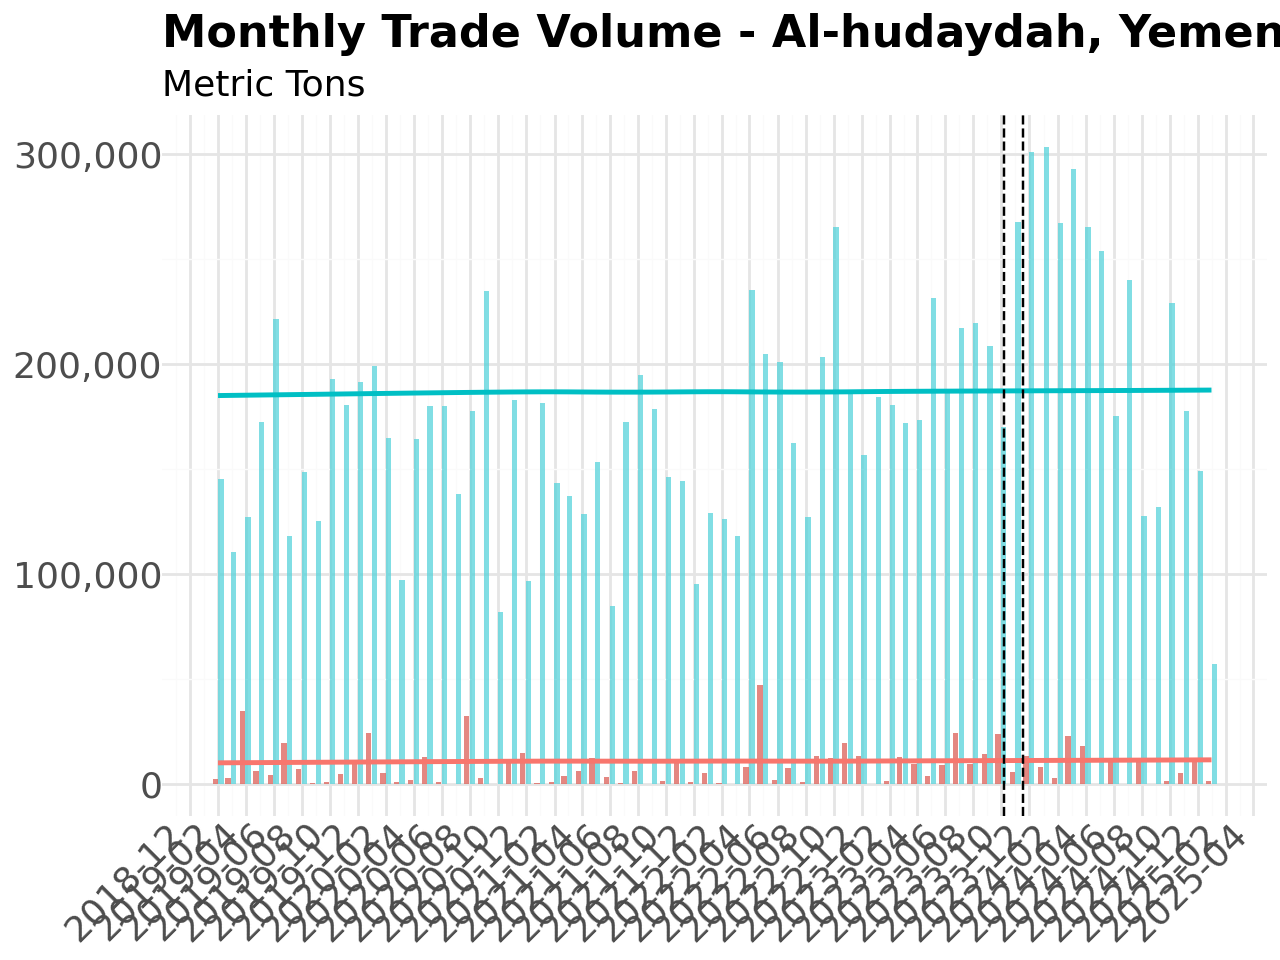

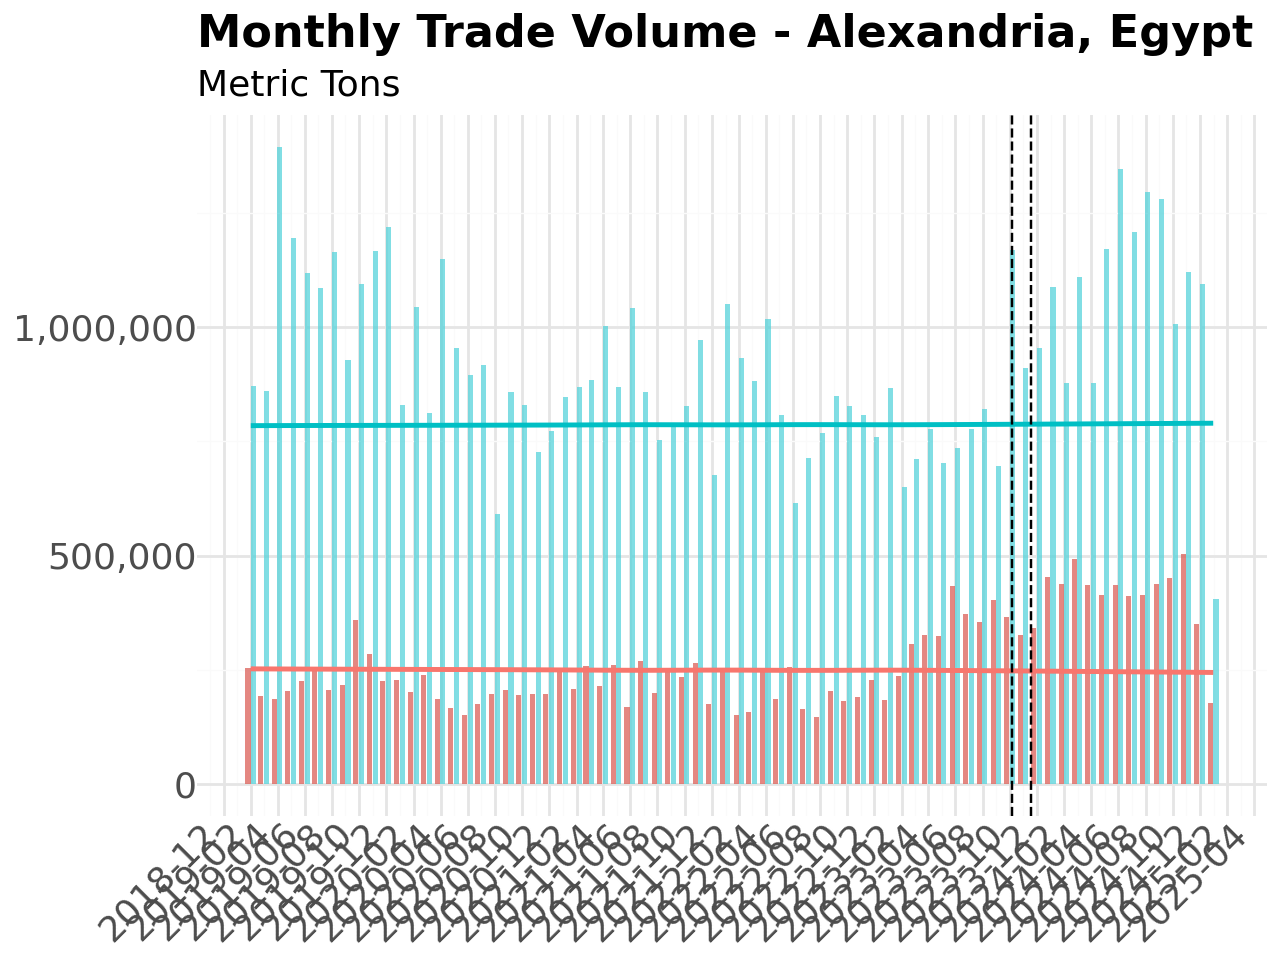

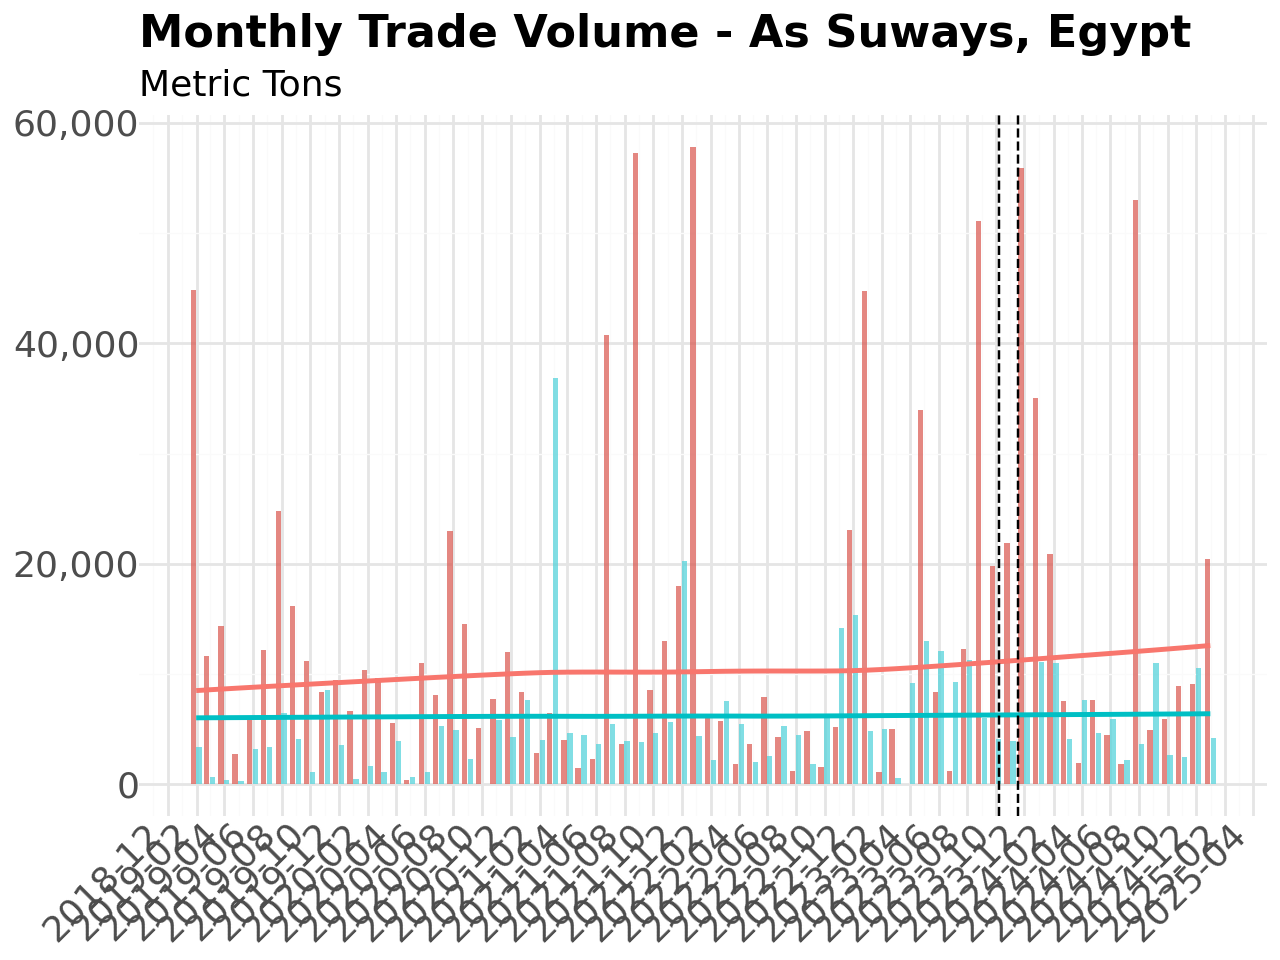

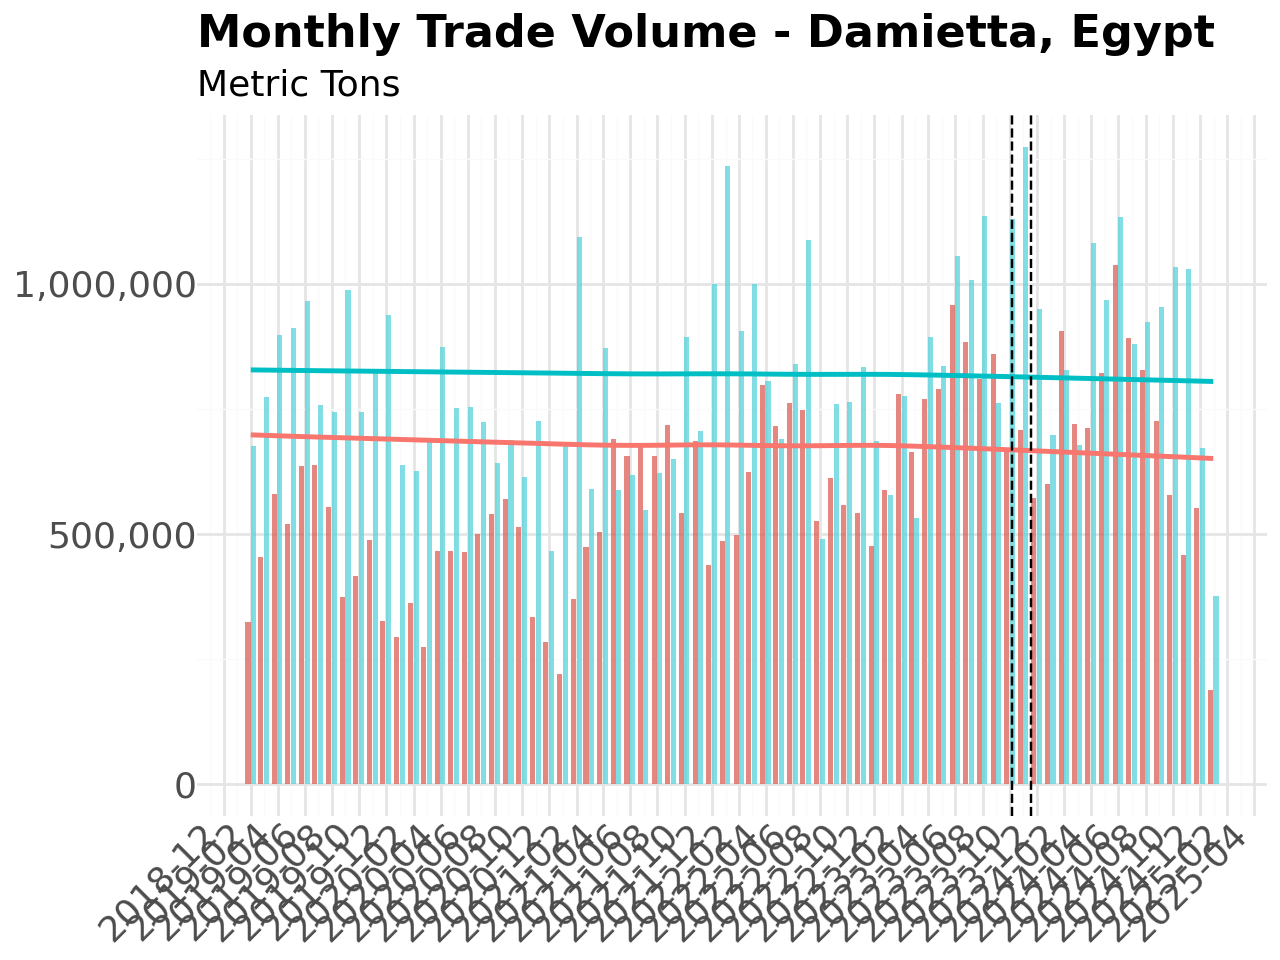

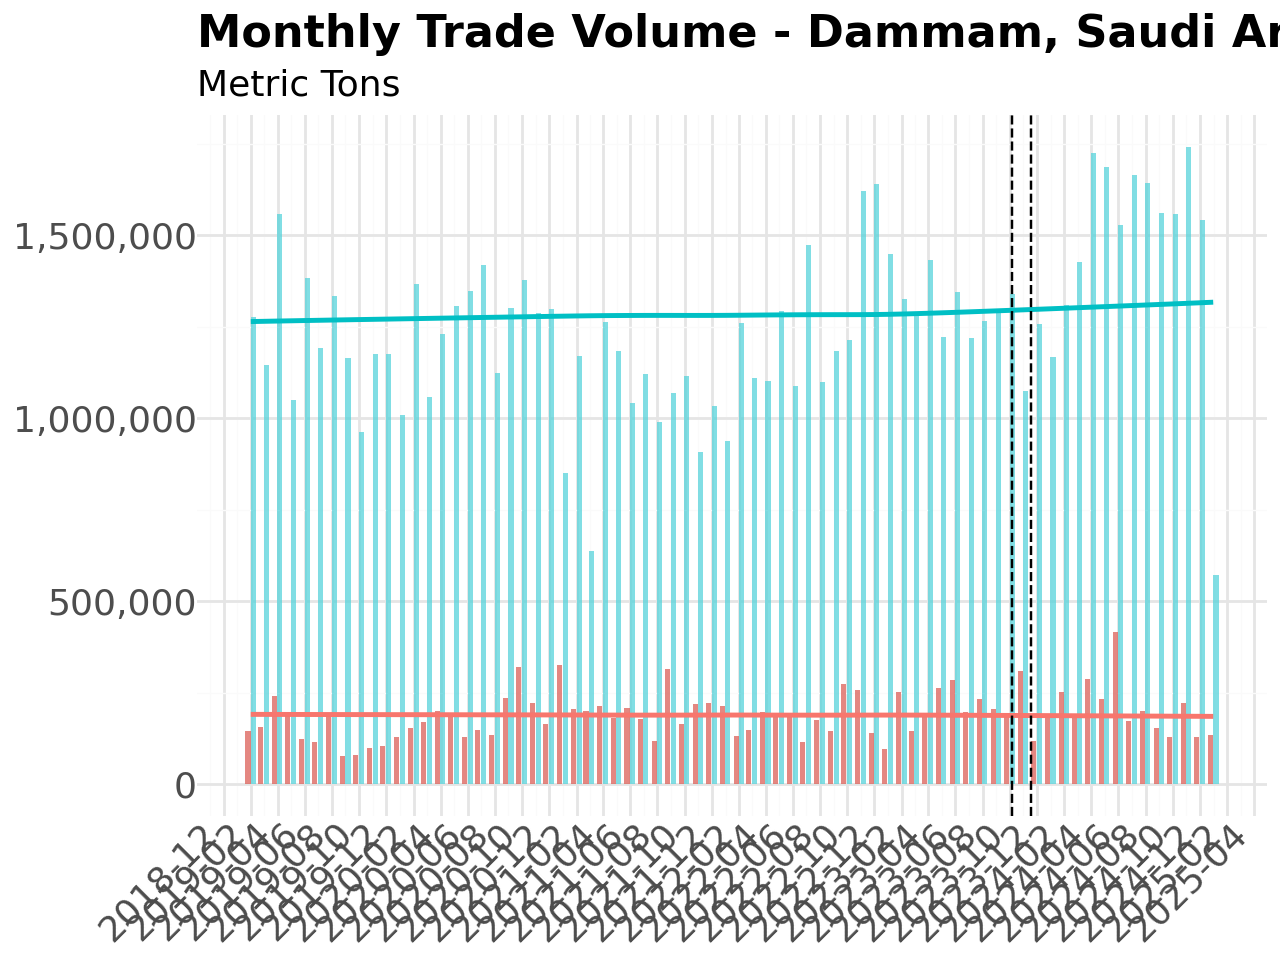

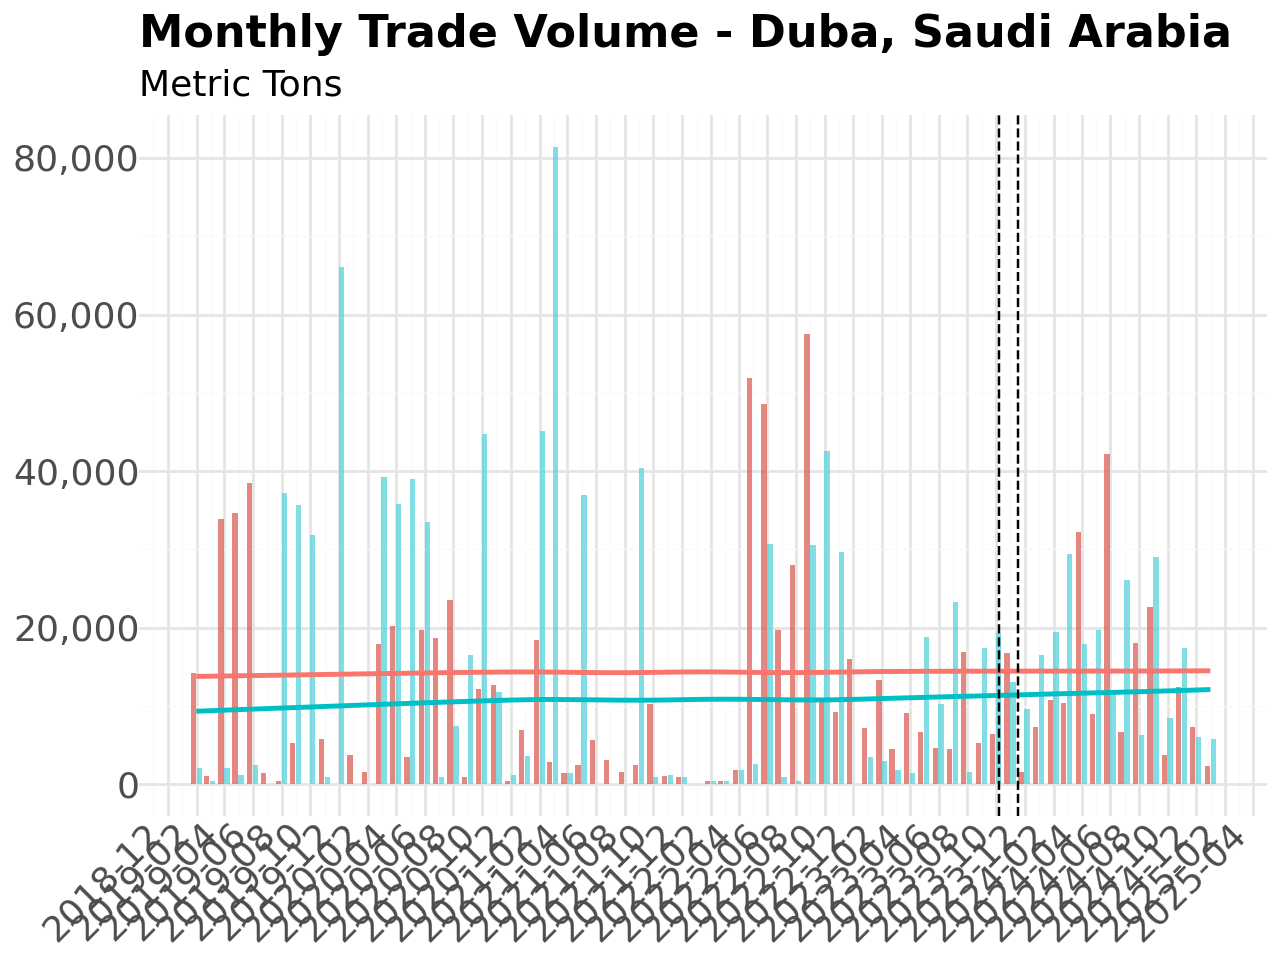

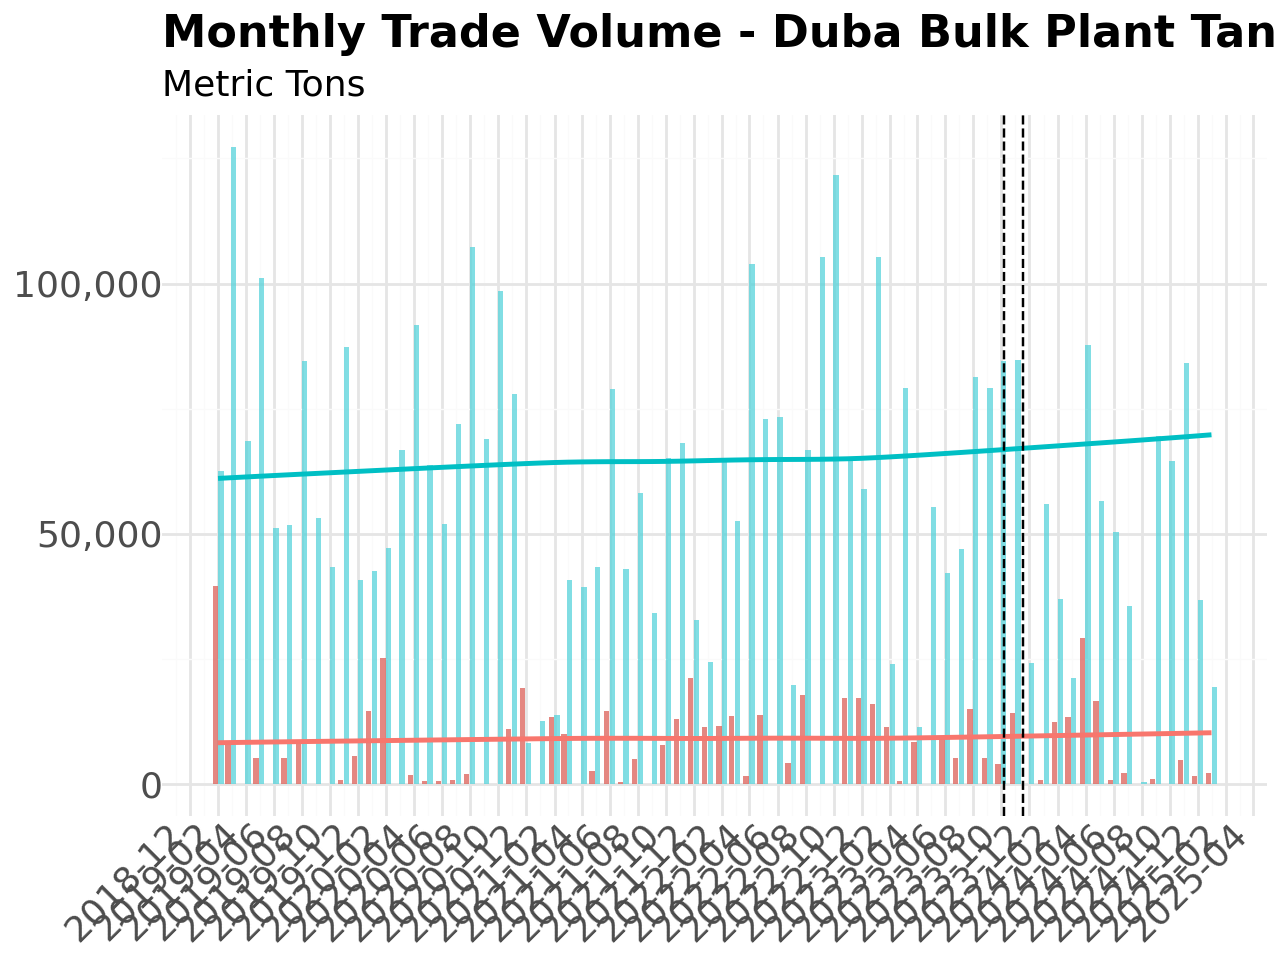

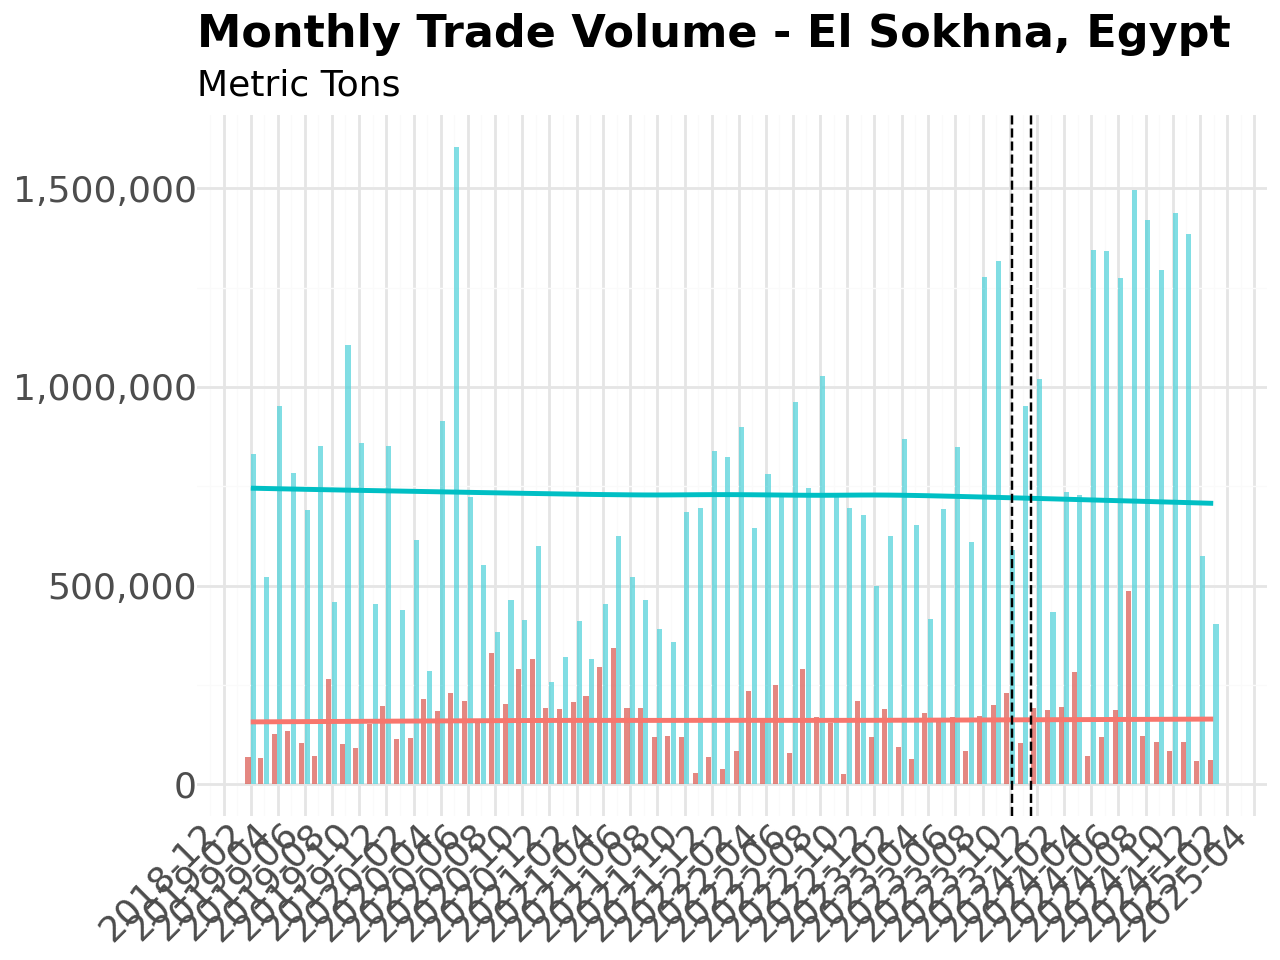

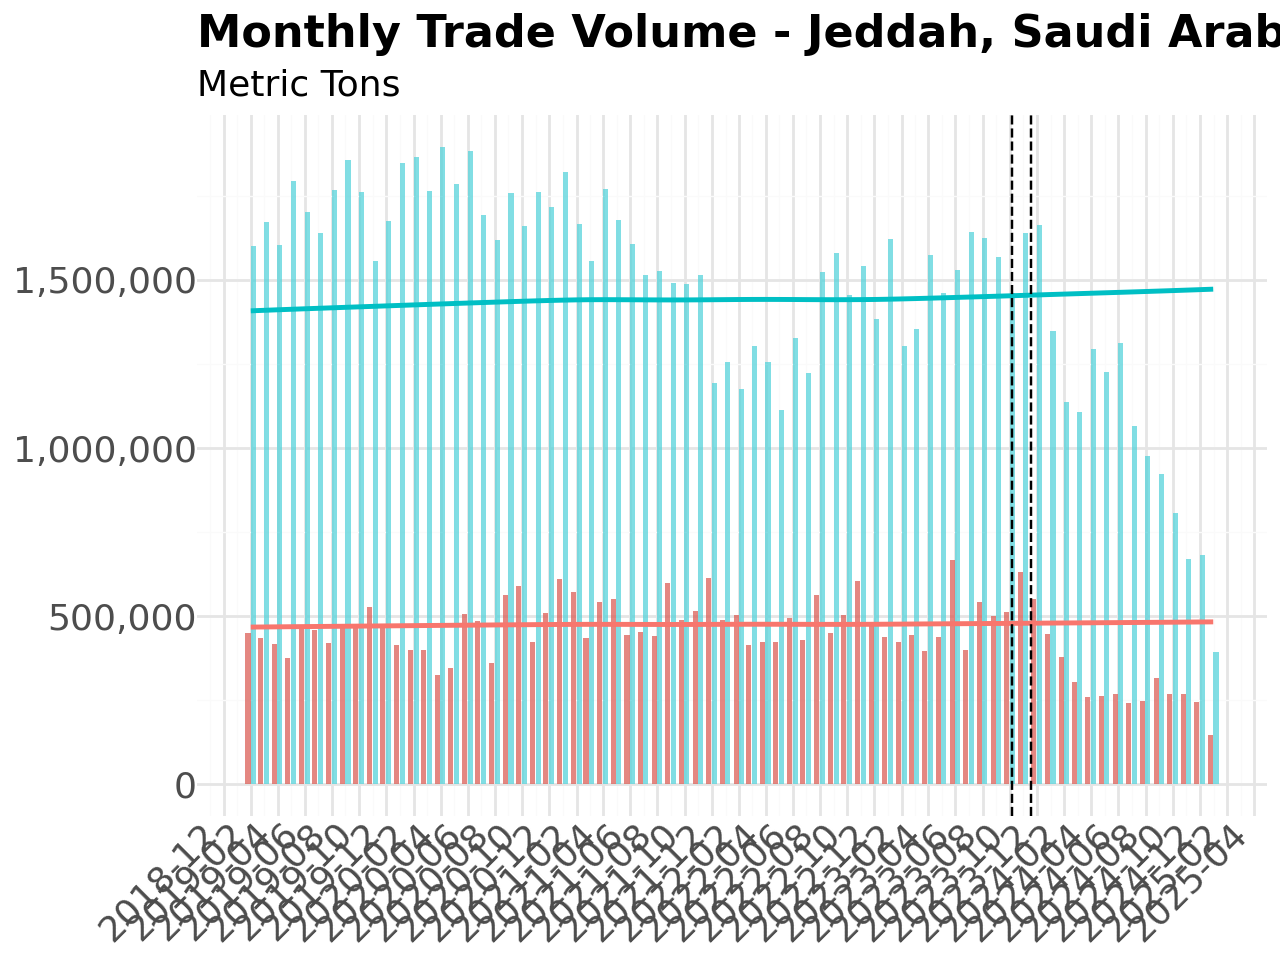

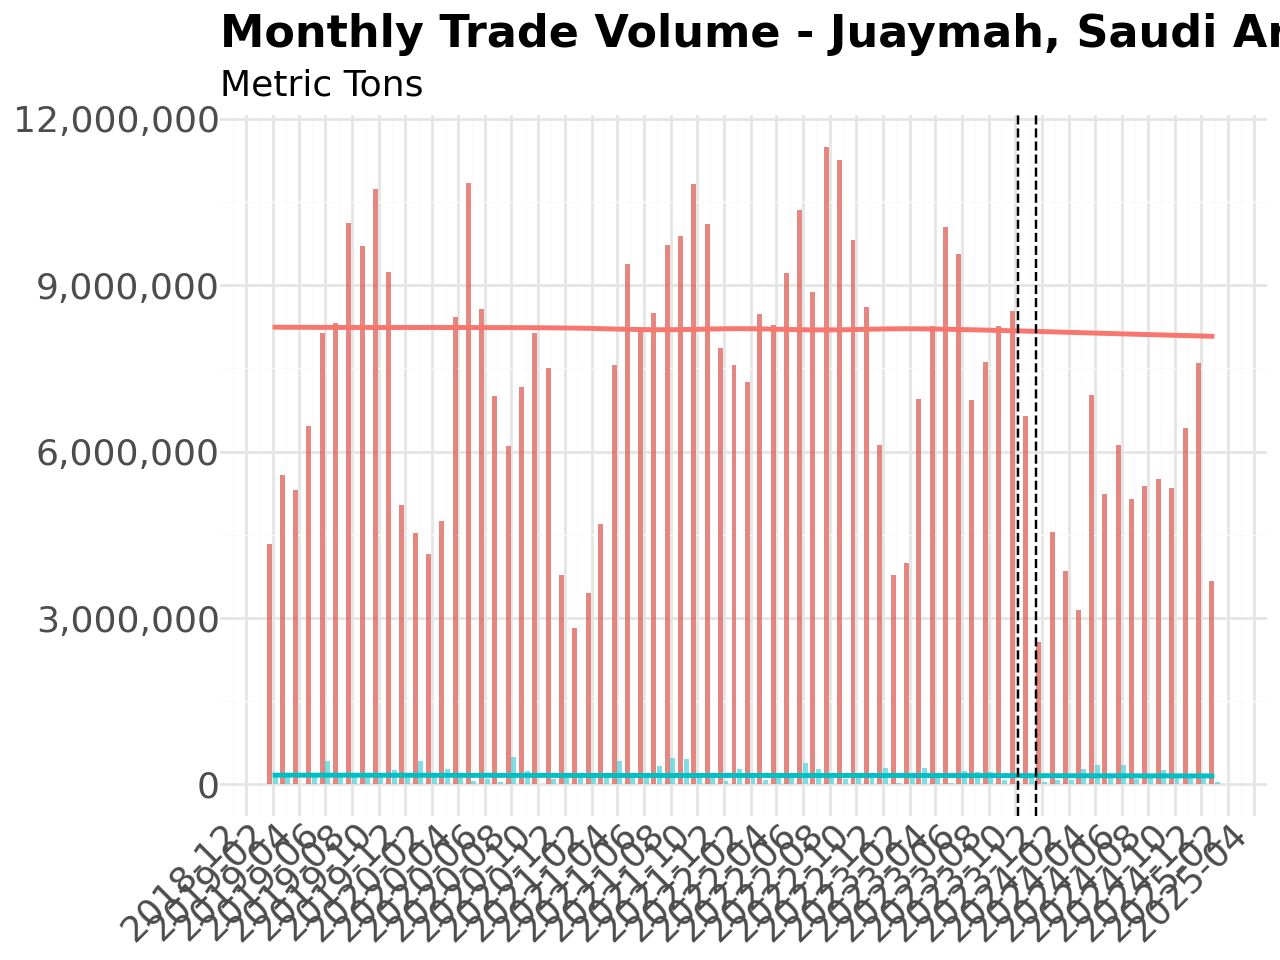

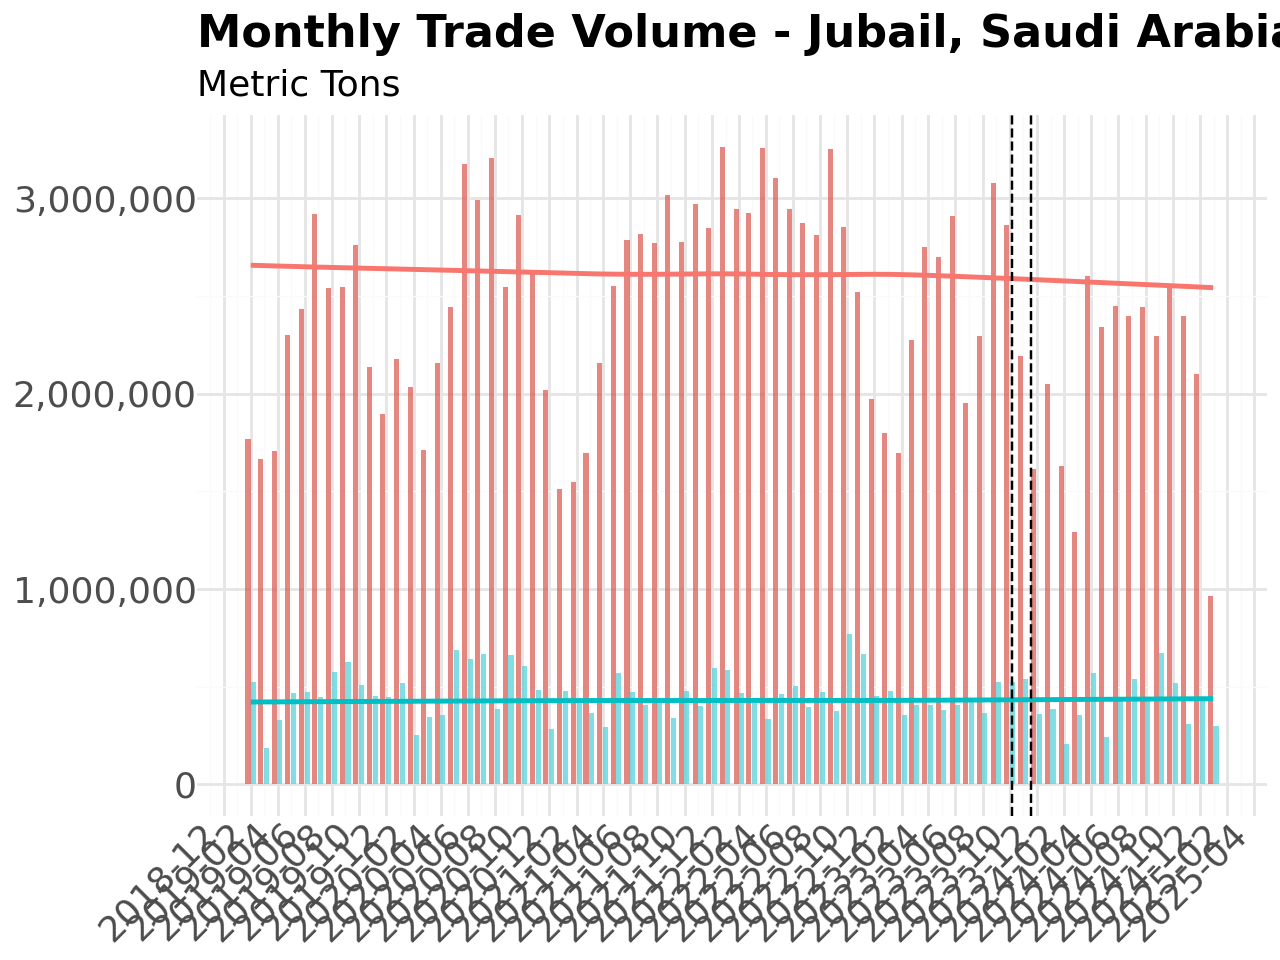

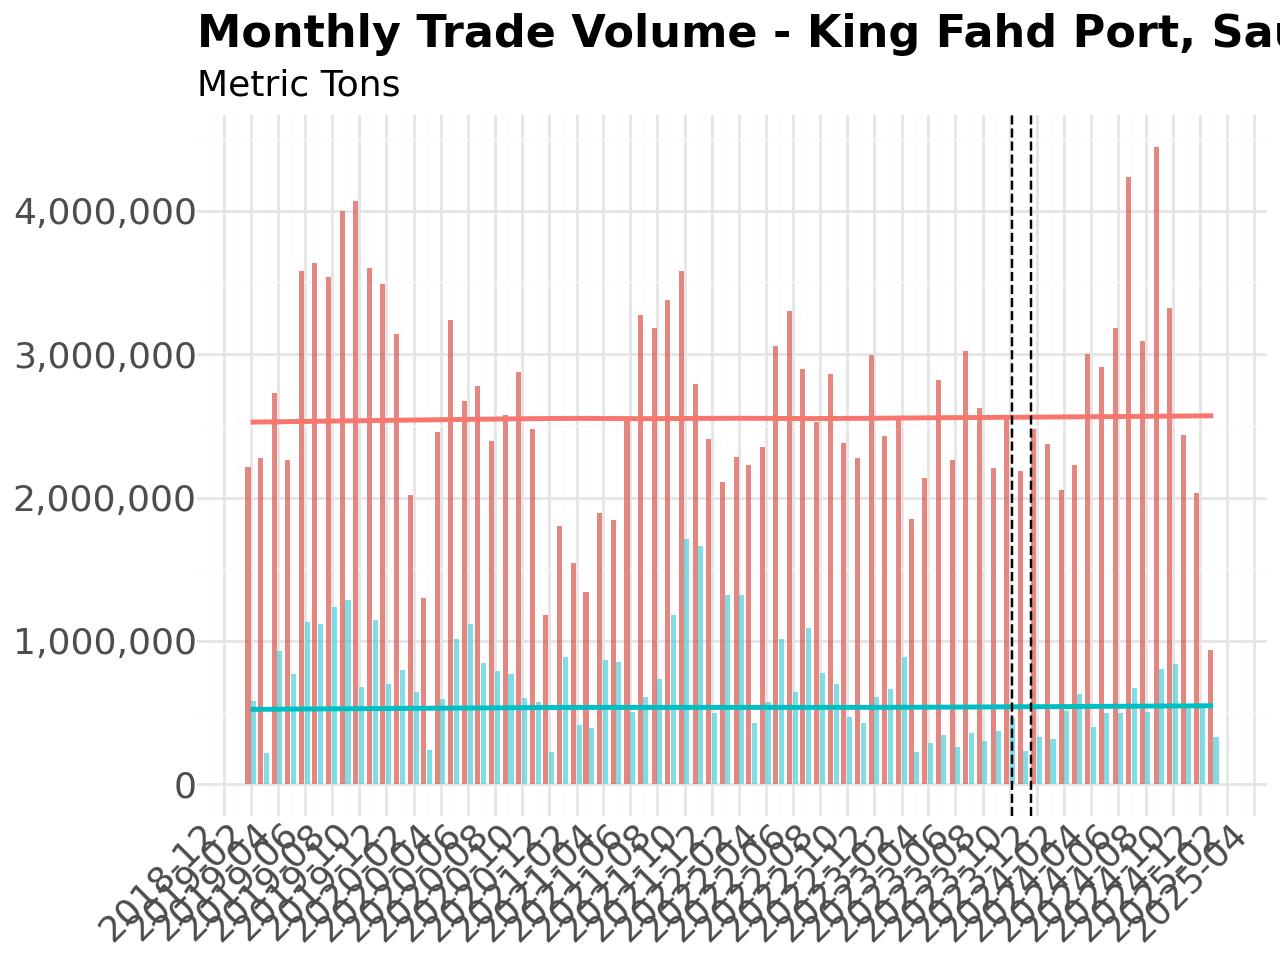

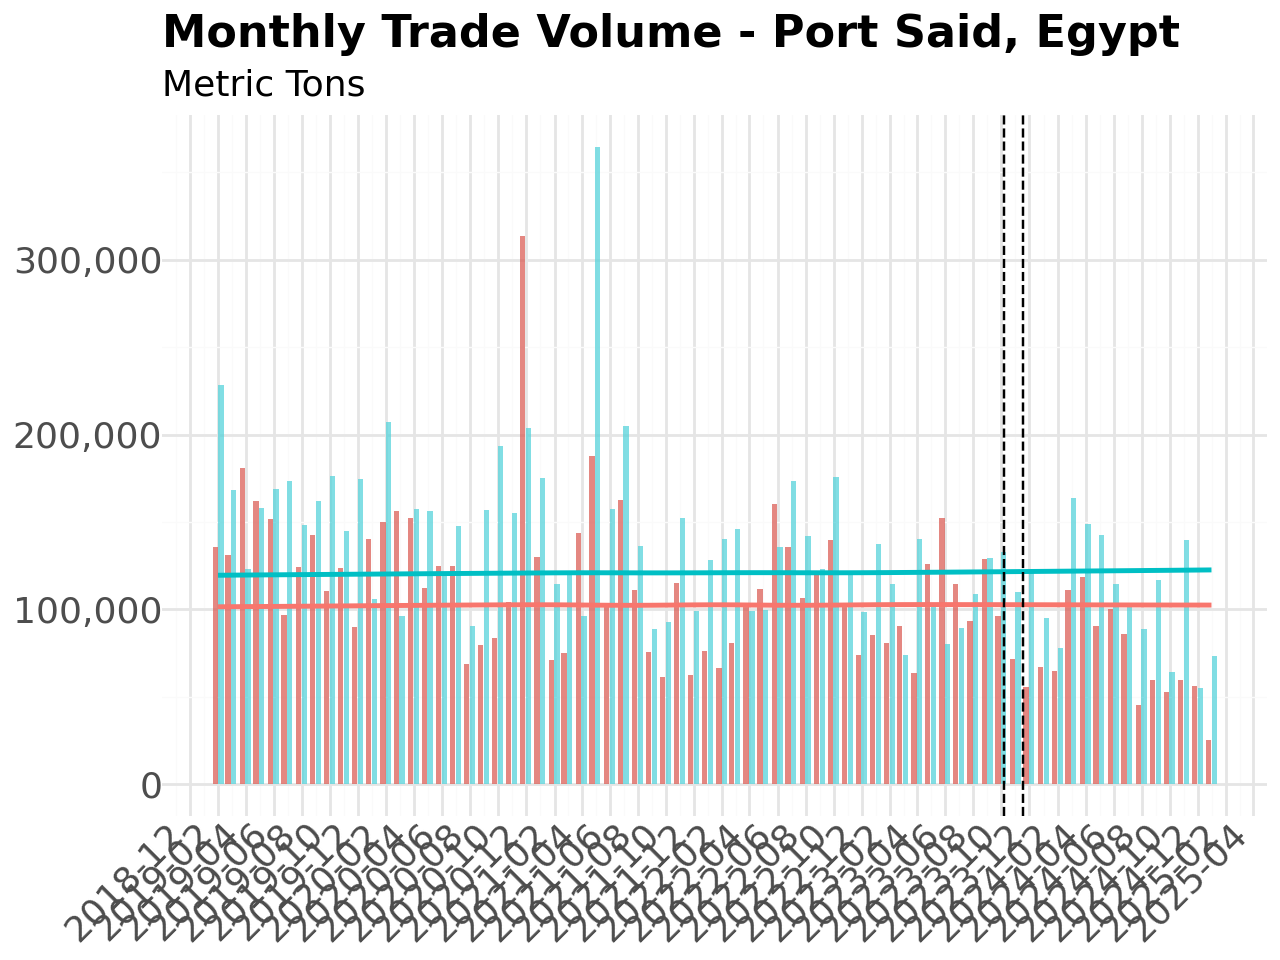

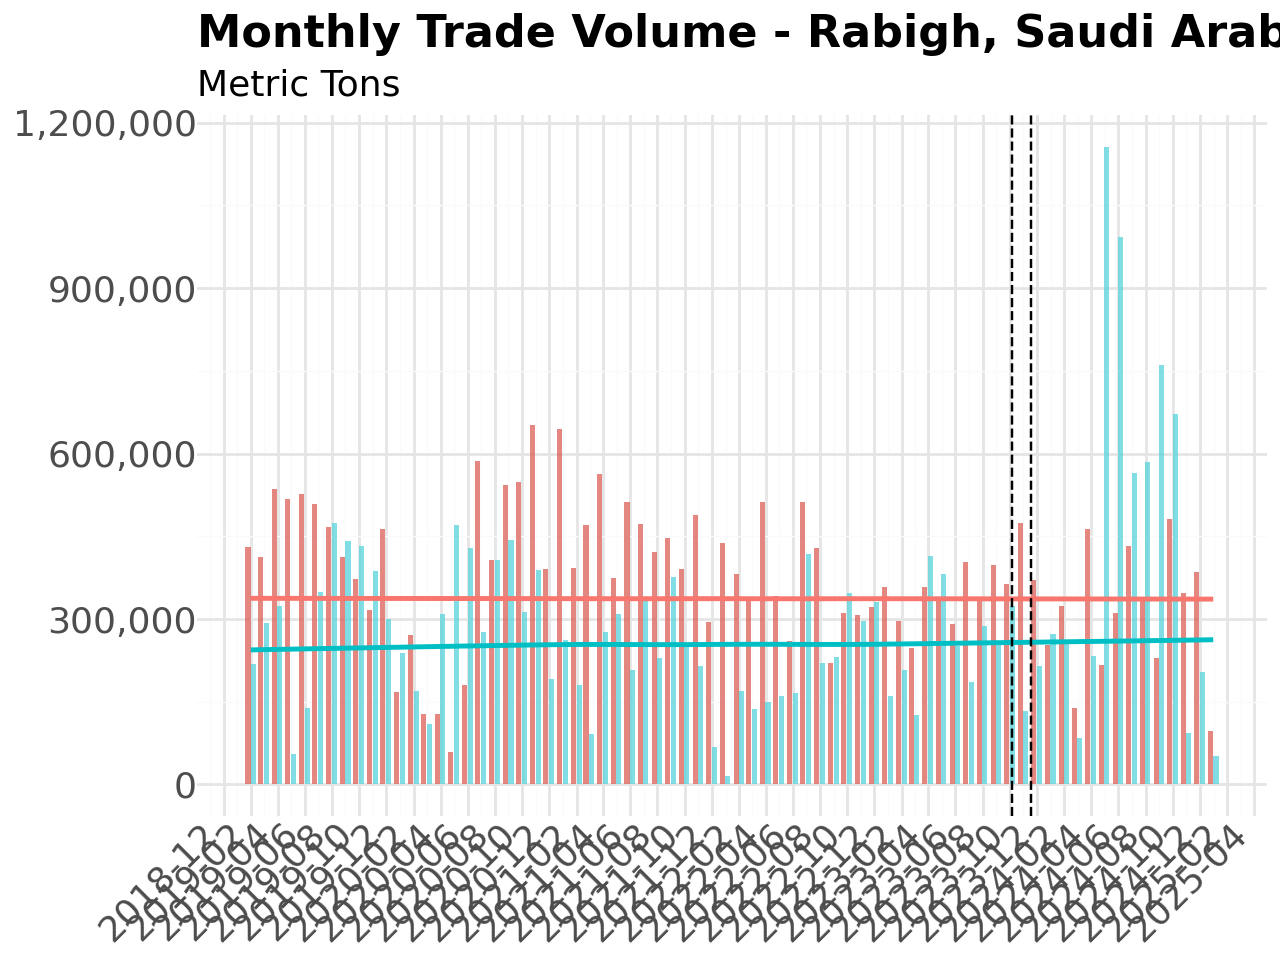

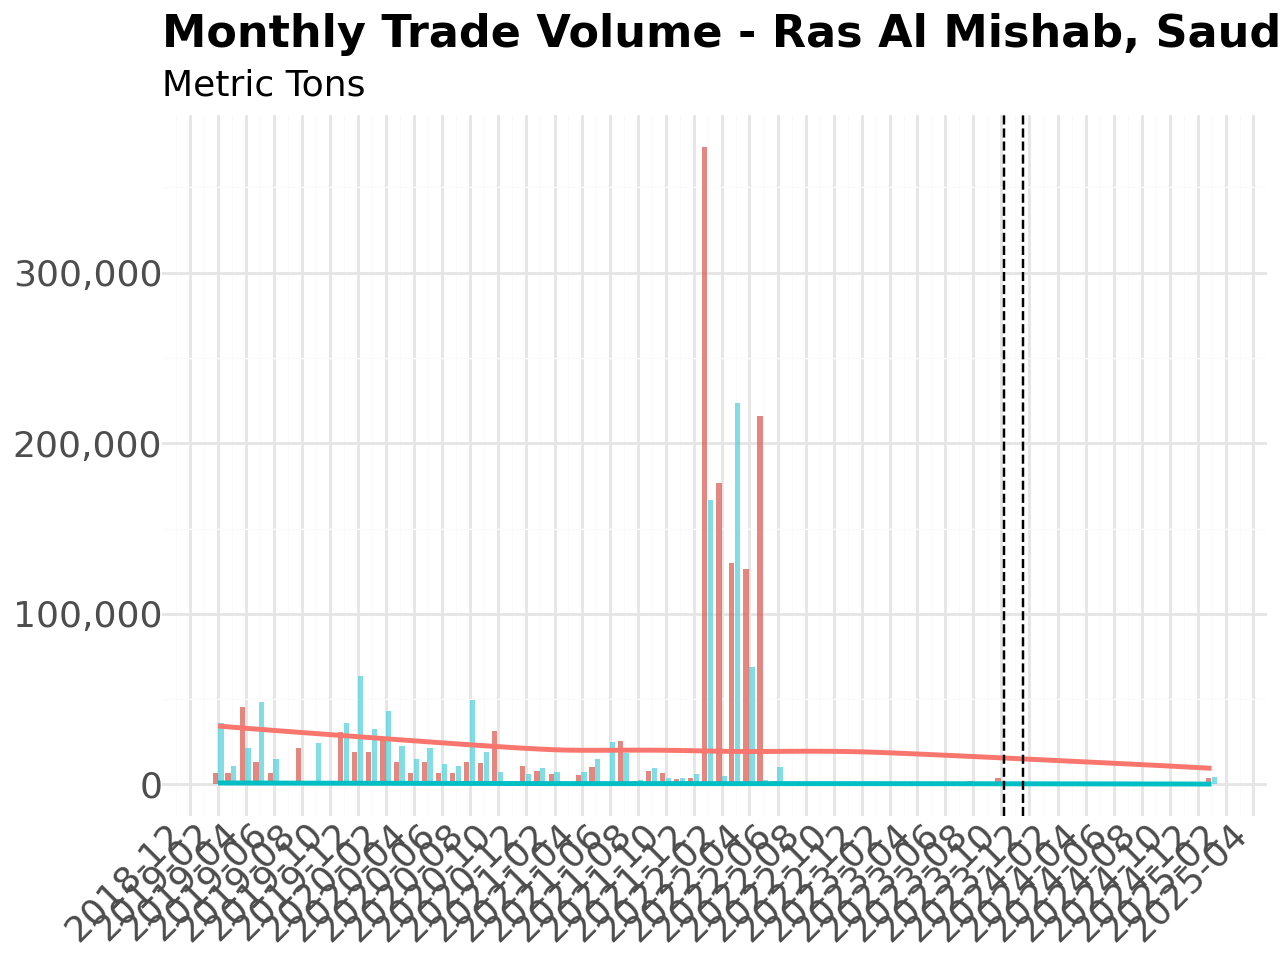

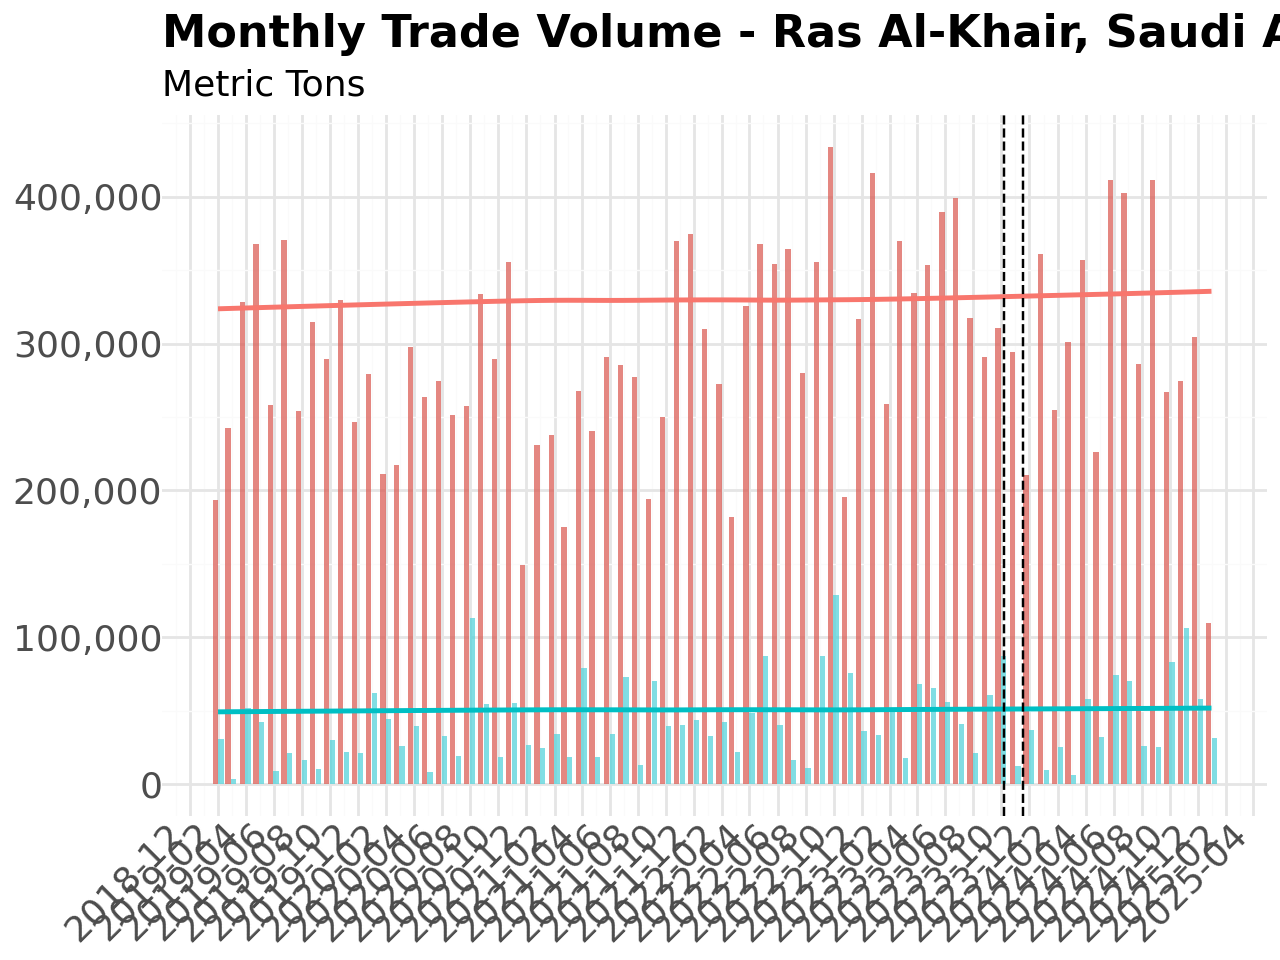

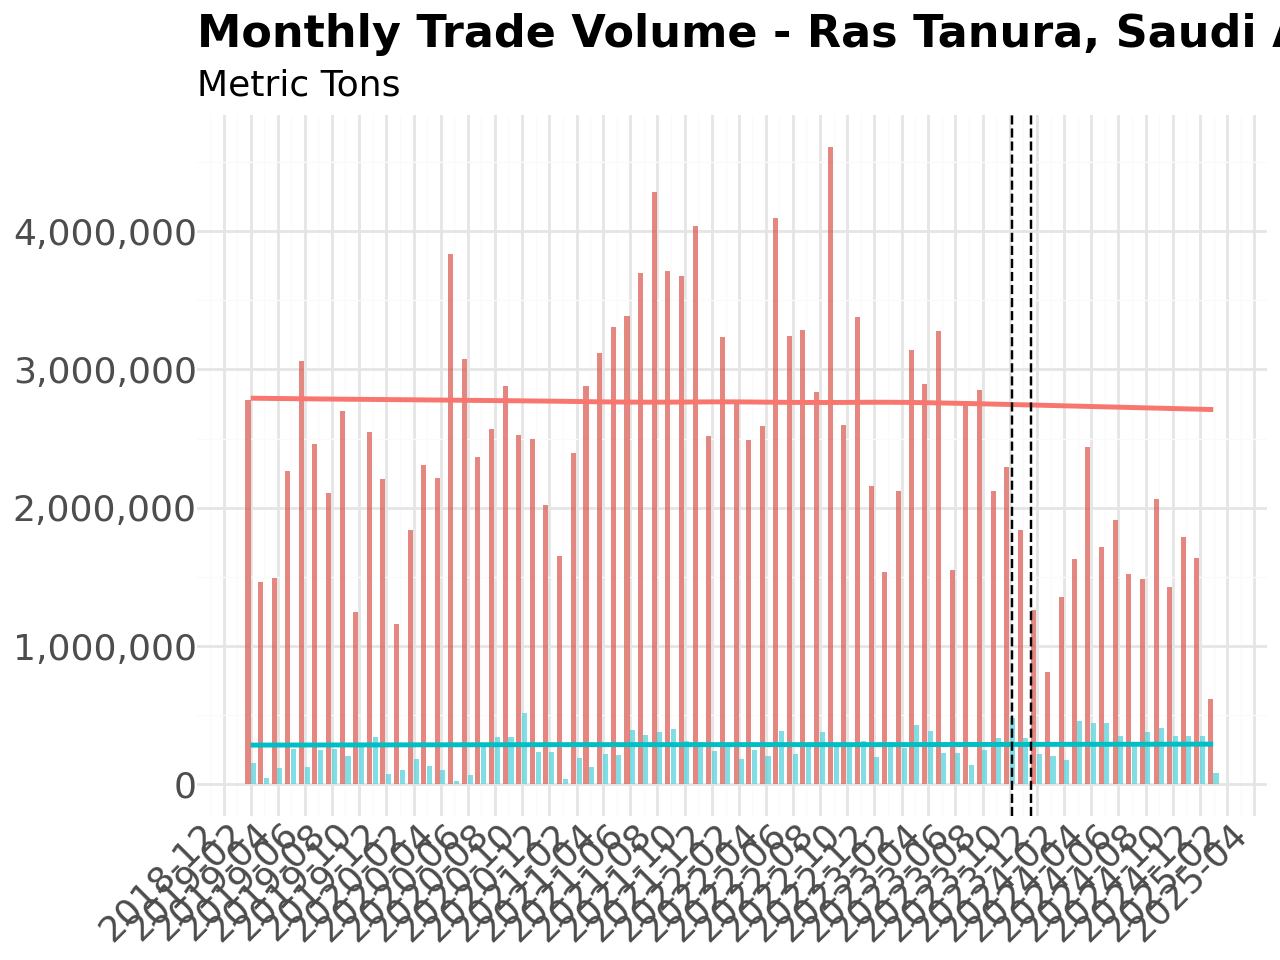

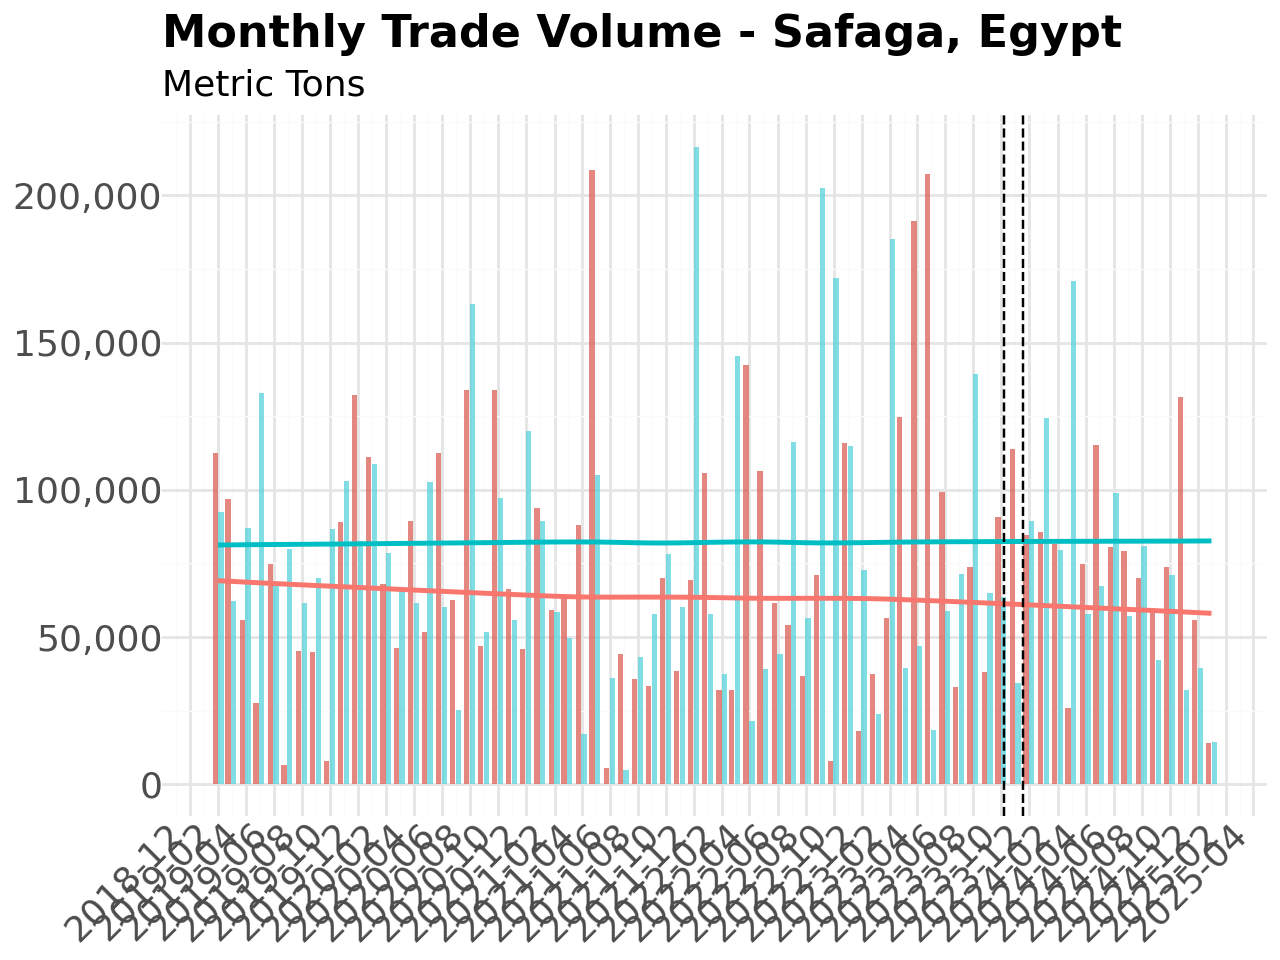

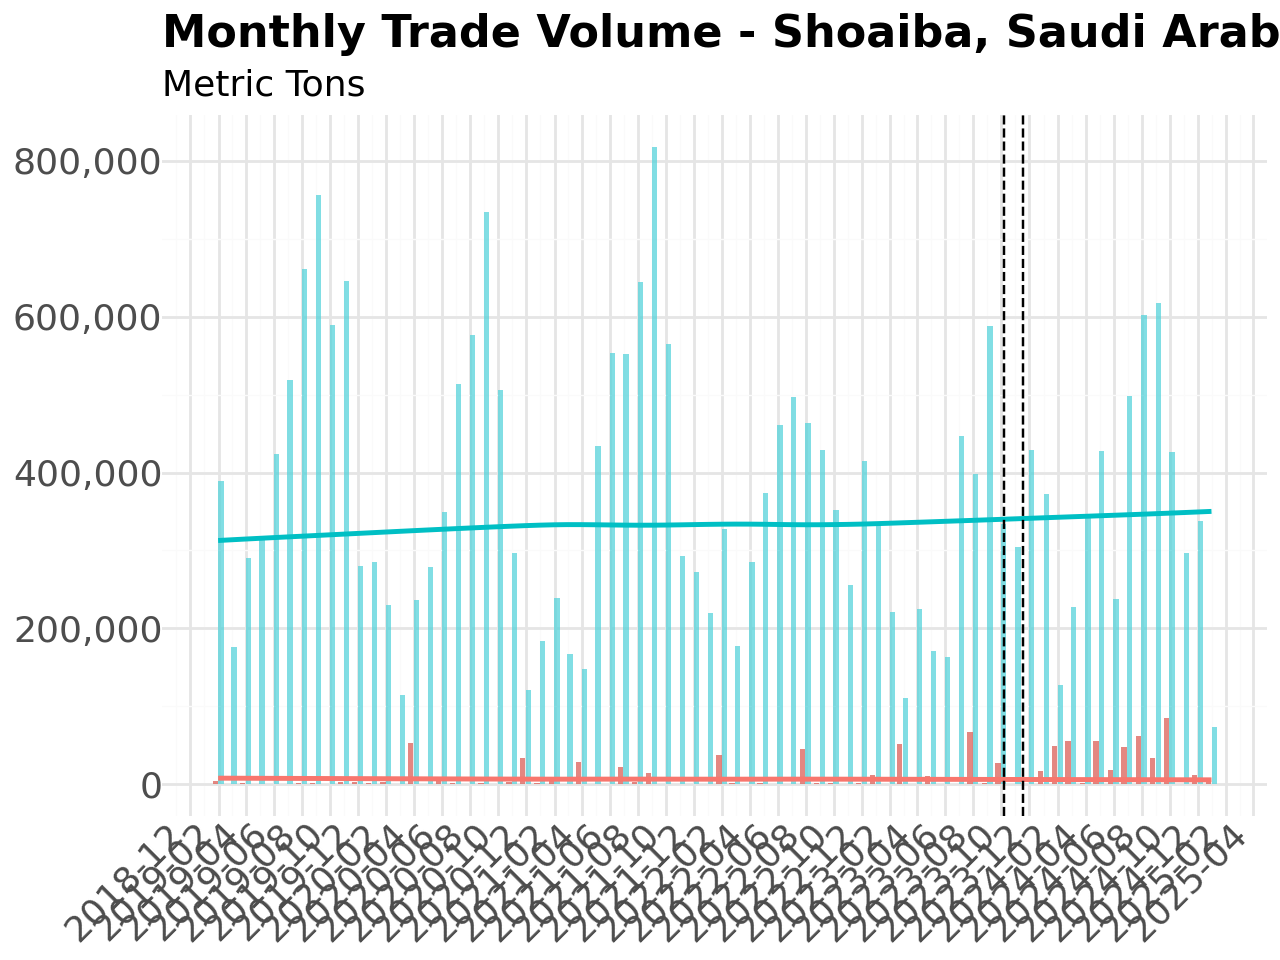

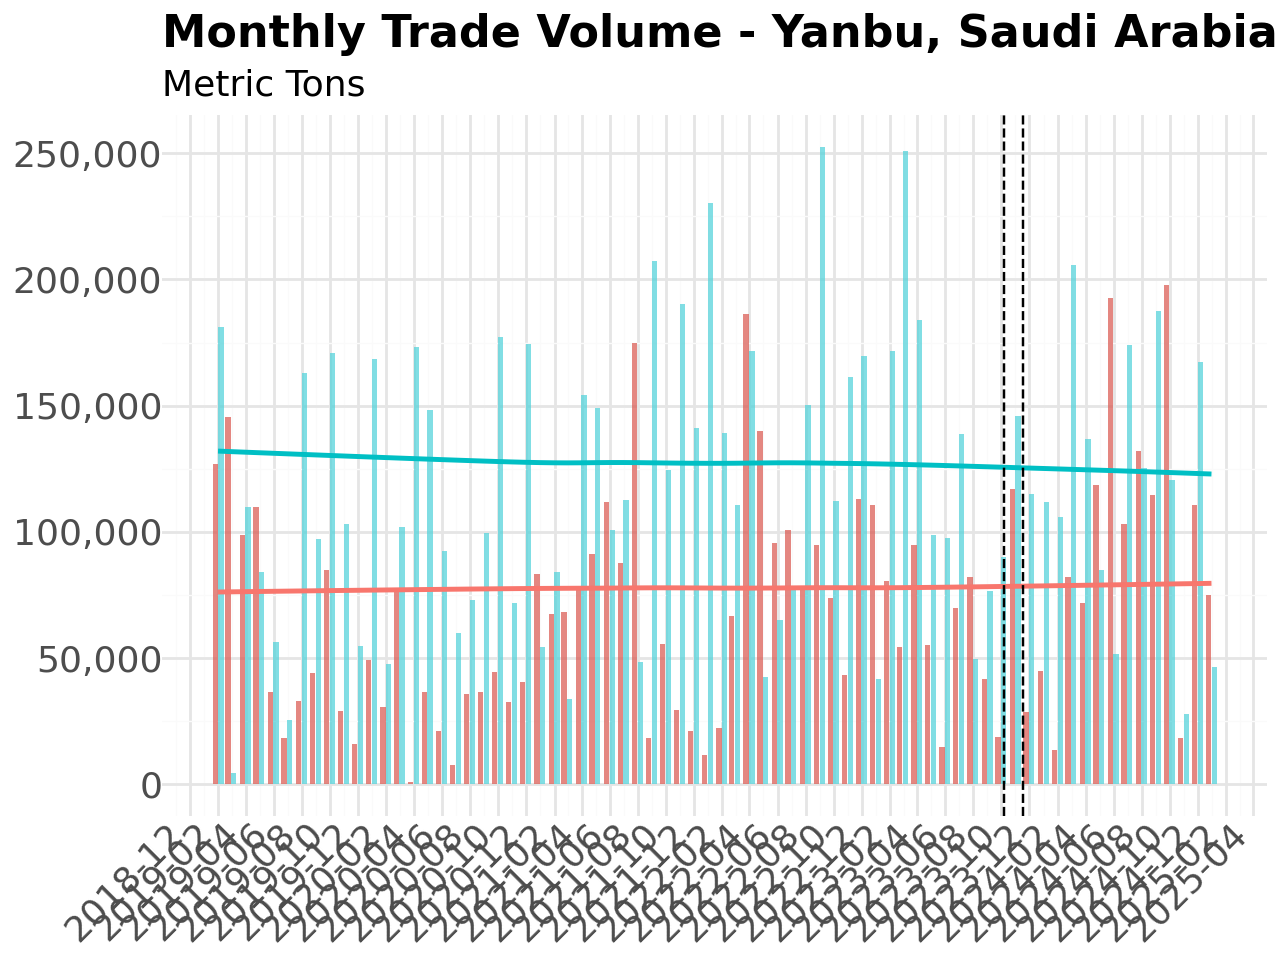

In [154]:
# Visualization for monthly trade
for port_id in df_month.portid.unique():
    port_info = ports_red_sea.loc[ports_red_sea.portid == port_id].iloc[0]
    country = port_info.country
    df_port = df_month.loc[df_month.portid == port_id].copy()
    df_port_copy = df_port.copy()
    port = df_port_copy.iloc[0].portname

    df_port = df_port.melt(
        id_vars="date",
        value_vars=["import", "export"],
        var_name="direction",
        value_name="trade",
    )
    df_port.loc[:, "direction"] = df_port.direction.str.capitalize()

    p0 = (
        ggplot(df_port_copy, aes(x="date", y="import_ref"))  #
        + geom_bar(
            mapping=aes(x="date", y="trade", fill="direction"),
            data=df_port,
            alpha=3 / 4,
            stat="identity",
            position="dodge2",
        )
        + geom_smooth(
            mapping=aes(x="date", y="import_ref"), color="#00BFC4", size=1, alpha=3 / 4
        )
        + geom_smooth(
            mapping=aes(x="date", y="export_ref"), color="#F8766D", size=1, alpha=3 / 4
        )
        + geom_vline(xintercept=conflict_date, linetype="dashed", color="black")
        + geom_vline(xintercept=crisis_date, linetype="dashed", color="black")
        + labs(
            x="",
            y="",
            subtitle="Metric Tons",
            title=f"Monthly Trade Volume - {port}, {country}",
            fill="Trade Flow",
        )
        + theme_minimal()
        + theme(
            text=element_text(size=13),
            plot_title=element_text(size=16, weight="bold"),
            axis_text_x=element_text(rotation=45, hjust=1),
            legend_position="none",
        )
        + scale_x_datetime(breaks=date_breaks("2 month"), labels=date_format("%Y-%m"))
        + scale_y_continuous(labels=comma_format())
    )
    display(p0)


## Summary statistics

Using the monthly data, follow a similar methodology as the one used in the chokepoints analysis and calculate monthly average values for each time period of interest:


- **Baseline**: January 1st, 2022 – October 6th, 2023
- **Middle East Conflict**: October 7th, 2023 - November 16th, 2023
- **Red Sea Crisis**: November 17th, 2023 - February 19th, 2024

Your table shoud look like this:
|Country|Port|Period|Cargo Import|Cargo Export|Tanker Import|Tanker Export|Total Import|Total Export|
|--|--|--|--|--|--|--|--|--|
|Djibouti|Djibouti|Reference|--|--|--|--|--|--|
|Djibouti|Djibouti|Middle East Conflict|--|--|--|--|--|--|
|Djibouti|Djibouti|Red Sea Crisis|--|--|--|--|--|--|

```{note}
Notice that for each port, there will be 3 datapoints, Baseline, Middle East Conflict and Red Sea Crisis. 
```
Once your table is ready, calculate the percentage change from the baseline for each conflict and port. The new table should look like follows:
|Country|Port|Period|Cargo Import|Cargo Export|Tanker Import|Tanker Export|Total Import|Total Export|
|--|--|--|--|--|--|--|--|--|
|Djibouti|Djibouti|Middle East Conflict|--|--|--|--|--|--|
|Djibouti|Djibouti|Red Sea Crisis|--|--|--|--|--|--|

In [155]:
start_reference_date = '2022-01-01'
end_reference_date = '2023-10-06'
start_conflict_date = '2023-10-07'
end_conflict_date = '2023-11-16'
start_crisis_date = '2023-11-17'
end_crisis_date = '2024-02-19'

In [156]:
# Define the periods
df_month["period"] = ""
df_month.loc[(df_month.date >= start_reference_date) & (df_month.date < end_reference_date), "period"] = "Reference"

df_month.loc[(df_month.date >= start_conflict_date) & (df_month.date < end_conflict_date), "period"] = "Middle East Conflict"

df_month.loc[(df_month.date >= start_crisis_date) & (df_month.date < end_crisis_date), "period"] = "Red Sea Crisis"

df_periods = df_month.loc[df_month.period != ""] # Filter out rows without a period

In [157]:
# Aggregate data by portname, portid, and period
df_agg_month = (
    df_periods.groupby(["portname", "period"])[
        [
            "import_cargo",
            "export_cargo",
            "import_tanker",
            "export_tanker",
            "import",
            "export",
        ]
    ]
    .mean()
    .reset_index()
)

# Rename columns for clarity
df_agg_month.rename(
    columns={
        "import_cargo": "Cargo Import",
        "export_cargo": "Cargo Export",
        "import_tanker": "Tanker Import",
        "export_tanker": "Tanker Export",
        "import": "Total Import",
        "export": "Total Export",
    },
    inplace=True,
)

df_agg_month[["Cargo Import","Cargo Export","Tanker Import","Tanker Export","Total Import","Total Export",]] = df_agg_month[[
        "Cargo Import","Cargo Export", "Tanker Import","Tanker Export","Total Import","Total Export",]].apply(lambda x: round(x, 2))

In [158]:
df_agg_month

,portname,period,Cargo Import,Cargo Export,Tanker Import,Tanker Export,Total Import,Total Export
0,Aden,Middle East Conflict,207699.91,16829.63,0.00,0.00,207699.91,16829.63
1,Aden,Red Sea Crisis,155861.06,3516.87,27662.64,2061.52,183523.70,5578.39
2,Aden,Reference,252876.46,8498.83,43747.70,5786.04,296624.15,14284.88
3,Al Adabiyah,Middle East Conflict,11106.67,108115.30,76102.48,1550.07,87209.15,109665.38
4,Al Adabiyah,Red Sea Crisis,56725.73,152381.80,83330.47,561.07,140056.20,152942.87
...,...,...,...,...,...,...,...,...
67,Shoaiba,Red Sea Crisis,0.00,0.00,309446.29,22433.61,309446.29,22433.61
68,Shoaiba,Reference,0.00,0.00,334338.28,12548.32,334338.28,12548.32
69,Yanbu,Middle East Conflict,145785.52,116975.10,0.00,0.00,145785.52,116975.10
70,Yanbu,Red Sea Crisis,101939.08,29130.13,9085.11,0.00,111024.19,29130.13


## Summary Charts
Using the table calculated in the previous exercise, create bar plots showing the percentage change from baseline for:
* Middle East Conflict - Total Import
* Middle East Conflict - Total Export
* Red Sea - Total Import
* Red Sea - Total Export 

Please sort ports by greatest difference (absolute values). As a reference, your chart should look like follows (ignore the results):


In [168]:
df_baseline = df_agg_month[df_agg_month['period'] == 'Reference'].set_index('portname')
df_filtered = df_agg_month[df_agg_month['period'].isin(['Middle East Conflict', 'Red Sea Crisis'])].set_index('portname') # filter

df_filtered[['Baseline Total Import', 'Baseline Total Export']] = df_baseline[['Total Import', 'Total Export']] # assign baseline values to df_filtered

In [169]:
# Percentage change from baseline 
df_filtered['Percentage Change Total Import'] = ((df_filtered['Total Import'] - df_filtered['Baseline Total Import']) / df_filtered['Baseline Total Import']) * 100
df_filtered['Percentage Change Total Export'] = ((df_filtered['Total Export'] - df_filtered['Baseline Total Export']) / df_filtered['Baseline Total Export']) * 100
df_filtered[["Percentage Change Total Export","Percentage Change Total Import"]] = df_filtered[["Percentage Change Total Export","Percentage Change Total Import"]].apply(lambda x: round(x, 2))

# absolute change columns
df_filtered['Absolute_Change_Total_Import'] = df_filtered['Percentage Change Total Import'].abs()
df_filtered['Absolute_Change_Total_Export'] = df_filtered['Percentage Change Total Export'].abs()

df_filtered

,period,Cargo Import,Cargo Export,Tanker Import,Tanker Export,Total Import,Total Export,Baseline Total Import,Baseline Total Export,Percentage Change Total Import,Percentage Change Total Export,Absolute_Change_Total_Import,Absolute_Change_Total_Export
portname,,,,,,,,,,,,,
Aden,Middle East Conflict,207699.91,16829.63,0.00,0.00,207699.91,16829.63,296624.15,14284.88,-29.98,17.81,29.98,17.81
Aden,Red Sea Crisis,155861.06,3516.87,27662.64,2061.52,183523.70,5578.39,296624.15,14284.88,-38.13,-60.95,38.13,60.95
Al Adabiyah,Middle East Conflict,11106.67,108115.30,76102.48,1550.07,87209.15,109665.38,138998.15,124035.80,-37.26,-11.59,37.26,11.59
Al Adabiyah,Red Sea Crisis,56725.73,152381.80,83330.47,561.07,140056.20,152942.87,138998.15,124035.80,0.76,23.31,0.76,23.31
Al Aqabah,Middle East Conflict,529784.16,378157.66,117097.55,3703.40,646881.71,381861.06,651233.49,423386.28,-0.67,-9.81,0.67,9.81
Al Aqabah,Red Sea Crisis,333330.65,267965.97,73245.23,21840.10,406575.88,289806.07,651233.49,423386.28,-37.57,-31.55,37.57,31.55
Al Mukalla,Middle East Conflict,12832.39,9655.57,3693.59,0.00,16525.98,9655.57,32250.34,3130.01,-48.76,208.48,48.76,208.48
Al Mukalla,Red Sea Crisis,11234.87,243.44,14672.98,192.63,25907.85,436.07,32250.34,3130.01,-19.67,-86.07,19.67,86.07
Al-hudaydah,Middle East Conflict,249821.01,5837.84,18001.16,0.00,267822.17,5837.84,187464.14,11296.55,42.87,-48.32,42.87,48.32


In [170]:
conditions = [(df_filtered['Percentage Change Total Import'] > 0), (df_filtered['Percentage Change Total Export'] > 0)] # green for values > 0 , red for values < 0
colors = ['green', 'red']
df_filtered['color_category_import'] = np.select(conditions, colors, default='red')
df_filtered['color_category_export'] = np.select(conditions, colors, default='red')
df_filtered = df_filtered.reset_index()
#df_filtered['Percentage Change Total Import'] = df_filtered['Percentage Change Total Export'].apply(lambda x: round(x, 0))

In [184]:
from plotnine import scales

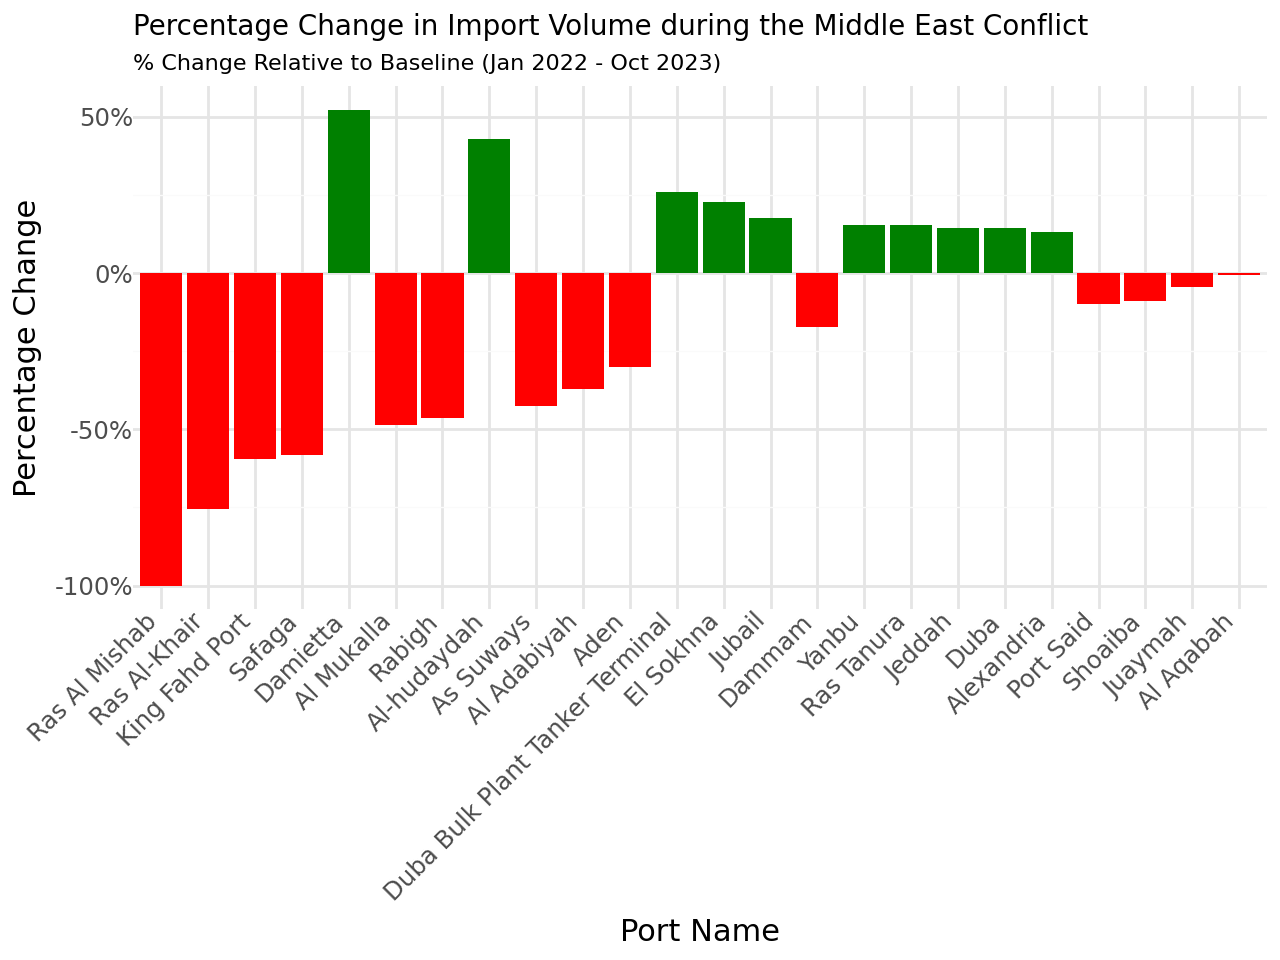

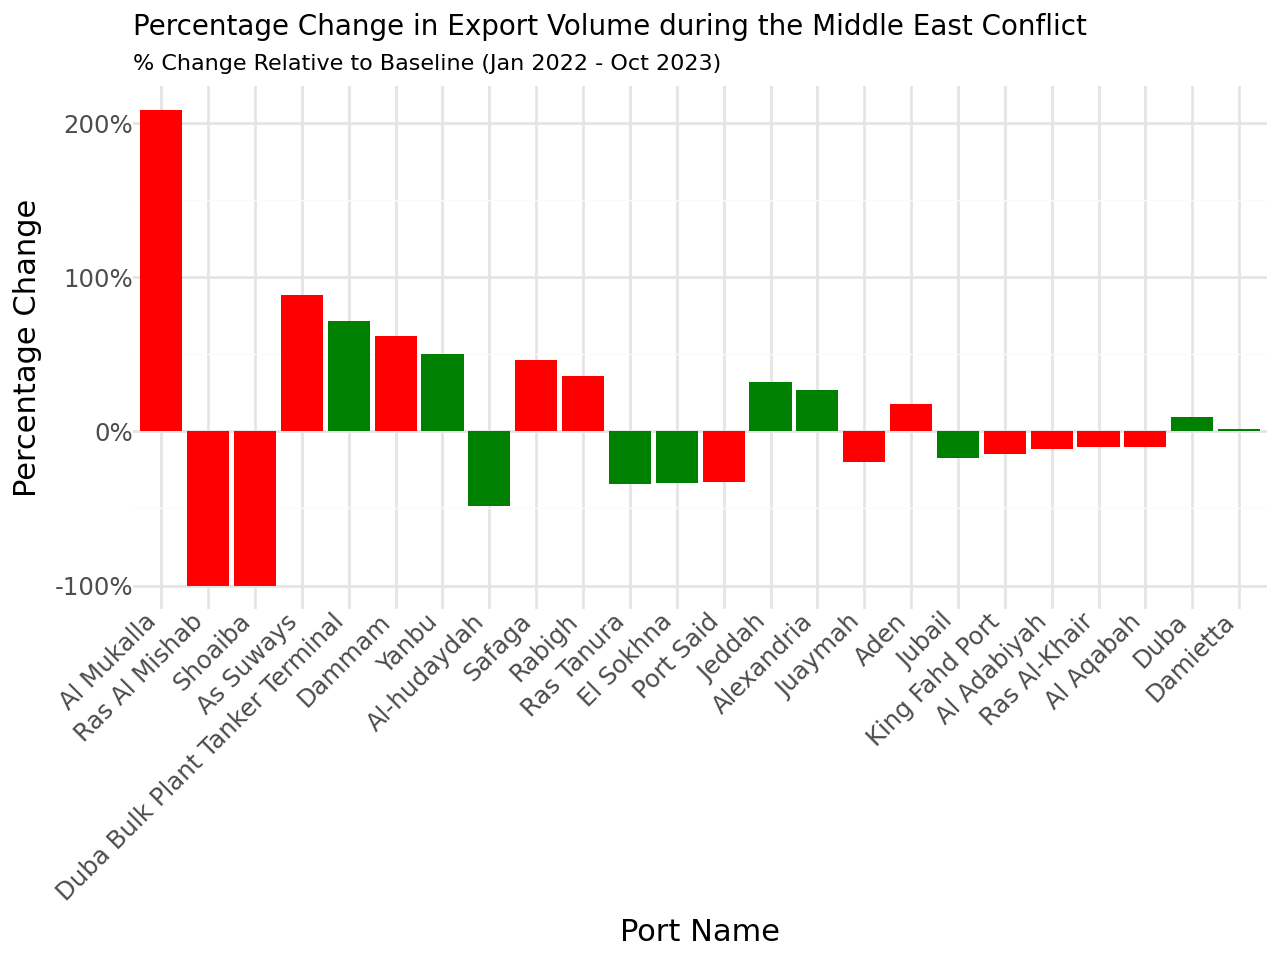

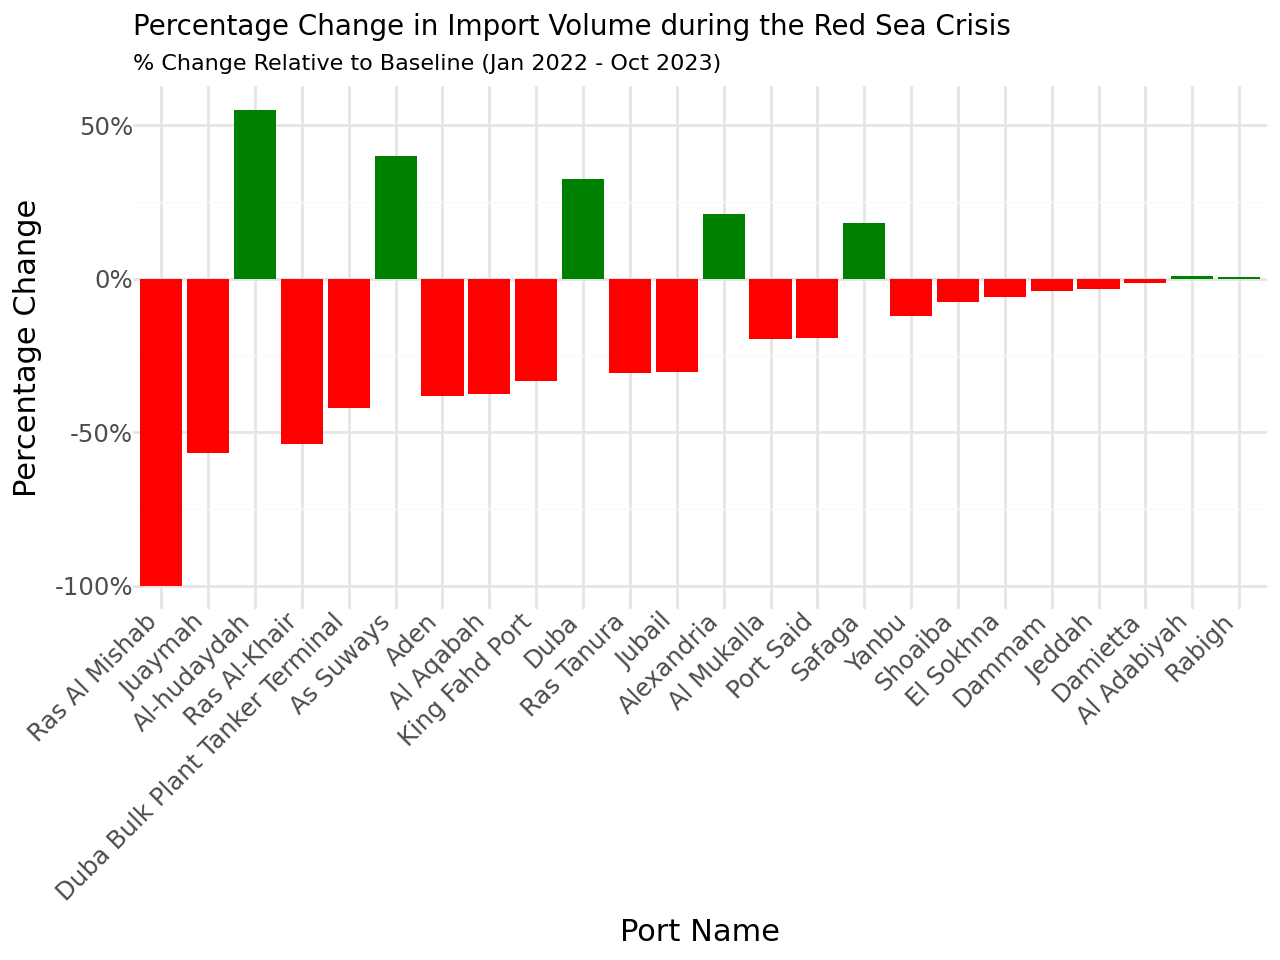

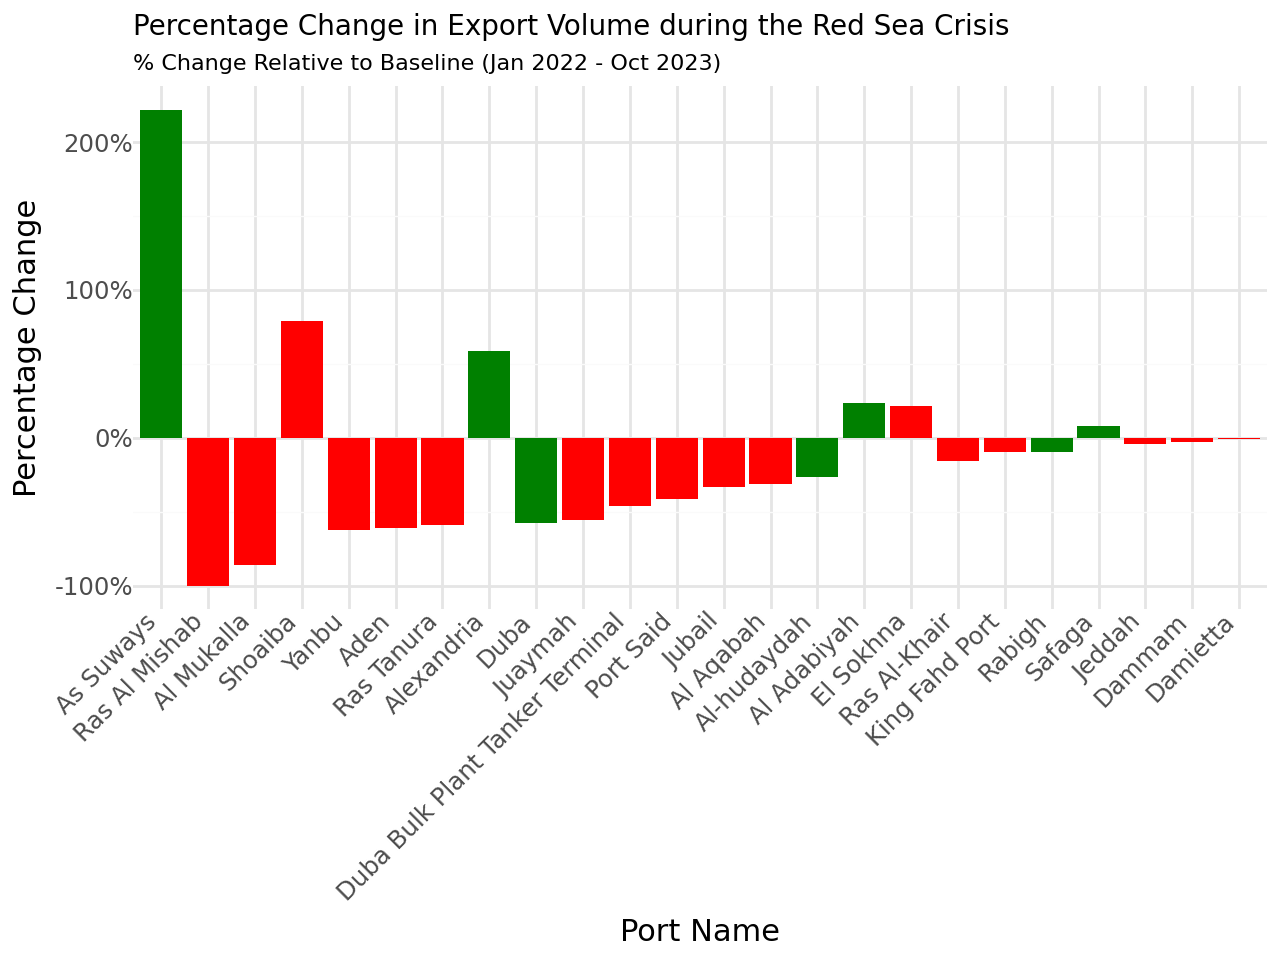

In [191]:
def create_plot(df, period, value_col, abs_change_col, title):
    df_period = df[df['period'] == period]
    #df_period[value_col] = df_period[value_col] * 100
    df_period[value_col] = df_period[value_col] / 100
    df_period_sorted = df_period.sort_values(by=abs_change_col, ascending=False)
    plot = (
        ggplot(df_period_sorted, aes(x='reorder(portname, -' + abs_change_col + ')', 
                                     y=value_col, fill='color_category_' + ('import' if 'Import' in value_col else 'export'))) +
        geom_bar(stat='identity', show_legend=False) +
        labs(title=title,
             subtitle='% Change Relative to Baseline (Jan 2022 - Oct 2023)',
             x='Port Name', y='Percentage Change') +
        scale_y_continuous(labels=percent_format()) +
        theme_minimal() +
        theme(plot_title=element_text(size=10), plot_subtitle=element_text(size=8),axis_text_x=element_text(angle=45, hjust=1)) +
        scale_fill_manual(values={'green': 'green', 'red': 'red'})
    )
    
    return plot

plot_import_mec = create_plot(df_filtered, 'Middle East Conflict', 'Percentage Change Total Import', 'Absolute_Change_Total_Import', 'Percentage Change in Import Volume during the Middle East Conflict')

plot_export_mec = create_plot(df_filtered, 'Middle East Conflict', 'Percentage Change Total Export', 'Absolute_Change_Total_Export', 'Percentage Change in Export Volume during the Middle East Conflict')

plot_import_rsc = create_plot(df_filtered, 'Red Sea Crisis', 'Percentage Change Total Import', 'Absolute_Change_Total_Import', 'Percentage Change in Import Volume during the Red Sea Crisis')

plot_export_rsc = create_plot(df_filtered, 'Red Sea Crisis', 'Percentage Change Total Export', 'Absolute_Change_Total_Export', 'Percentage Change in Export Volume during the Red Sea Crisis')

display(plot_import_mec)
display(plot_export_mec)
display(plot_import_rsc)
display(plot_export_rsc)